# Hedge Fund Industry X-Ray
## A 9-Source Reconstruction of U.S. Hedge Fund Balance Sheets, Derivatives & Broker Infrastructure (2012–2026)

**Data Sources:**
1. **Federal Reserve Z.1** — Table B.101.f, quarterly balance sheet of domestic hedge funds (29 series)
2. **SEC Form PF** — Fund-level GAV/NAV, strategy allocation, liquidity profiles (~1,500 large hedge funds)
3. **CFTC Weekly Swaps** — OTC swap notional outstanding by asset class and clearing status
4. **SEC EDGAR 13F** — Institutional equity holdings for 8 major hedge funds
5. **SEC EDGAR Submissions** — Filing history and fund metadata
6. **CFTC Commitments of Traders** — Leveraged fund positioning in futures markets
7. **CBOE VIX** — Market volatility index (daily → quarterly)
8. **DTCC Swap Repository** — Trade-level OTC derivatives data
9. **CFTC FCM Financials** — Futures broker capital adequacy and market concentration

**What makes this different:** Cross-source reconciliation — comparing the Fed's aggregate leverage ratio with Form PF's fund-level GAV/NAV, overlaying on-balance-sheet derivatives with OTC swap notionals, and connecting broker capital adequacy to clearing trends.

## 1. Setup & Imports

In [1]:
import os
import sys
import time
import warnings

import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import requests
from dotenv import load_dotenv
from fredapi import Fred
from matplotlib.ticker import FuncFormatter

warnings.filterwarnings("ignore")

# Add project root to path so src imports work from notebooks/
sys.path.insert(0, os.path.abspath(".."))

# Load environment variables
load_dotenv()
FRED_API_KEY = os.getenv("FRED_API_KEY")
fred = Fred(api_key=FRED_API_KEY)

# Plotting defaults
plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams["figure.figsize"] = (14, 6)
plt.rcParams["figure.dpi"] = 100
plt.rcParams["font.size"] = 12
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.labelsize"] = 12

# Tick formatters
fmt_billions = FuncFormatter(lambda x, _: f"${x:,.0f}B")
fmt_pct = FuncFormatter(lambda x, _: f"{x:.0f}%")
fmt_ratio = FuncFormatter(lambda x, _: f"{x:.2f}x")


def polish(ax, ylabel_fmt=None, date_axis=True):
    """Apply standard formatting: remove spines, set ticks, format axes."""
    ax.spines[["top", "right"]].set_visible(False)
    ax.grid(alpha=0.3)
    ax.tick_params(labelsize=10)
    if ylabel_fmt:
        ax.yaxis.set_major_formatter(ylabel_fmt)
    if date_axis:
        ax.xaxis.set_major_locator(mdates.YearLocator())
        ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
        plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, ha="right")


def merge_legends(ax1, ax2, **kwargs):
    """Combine legends from dual-axis chart onto ax1."""
    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    kw = {"loc": "upper left", "framealpha": 0.9, "edgecolor": "gray", "fontsize": 10}
    kw.update(kwargs)
    ax1.legend(lines1 + lines2, labels1 + labels2, **kw)
    if ax2.get_legend():
        ax2.get_legend().remove()


# Paths
DATA_DIR = os.path.join("..", "data", "raw")
os.makedirs(DATA_DIR, exist_ok=True)

print(f"FRED API key loaded: {'Yes' if FRED_API_KEY else 'No'}")

FRED API key loaded: Yes


## 2. Data Acquisition

### 2A. Federal Reserve Z.1 — Hedge Fund Balance Sheet (FRED API)

We fetch all 29 series from Table B.101.f (Balance Sheet of Domestic Hedge Funds) via the FRED API. Values are in **billions of USD**.

In [2]:
# FRED series ID mapping for B.101.f (Balance Sheet of Domestic Hedge Funds)
HEDGE_FUND_SERIES = {
    # Assets
    "Total assets": "BOGZ1FL624090005Q",
    "Foreign currency; asset": "BOGZ1FL623091003Q",
    "Deposits; asset": "BOGZ1FL623039003Q",
    "Other cash and cash equivalents; asset": "BOGZ1FL623039013Q",
    "Money market fund shares; asset": "BOGZ1FL623034003Q",
    "Security repurchase agreements; asset": "BOGZ1FL622051003Q",
    "Total debt securities; asset": "BOGZ1FL624022005Q",
    "Treasury securities; asset": "BOGZ1FL623061103Q",
    "Corporate and foreign bonds; asset": "BOGZ1FL623063003Q",
    "Total loans; asset": "BOGZ1FL623069005Q",
    "Leveraged loans; asset": "BOGZ1FL623069503Q",
    "Other loans; asset": "BOGZ1FL623069003Q",
    "Corporate equities; asset": "BOGZ1FL623064103Q",
    "Miscellaneous assets; asset": "BOGZ1FL623093005Q",
    # Liabilities
    "Total liabilities": "BOGZ1FL624190005Q",
    "Total security repurchase agreements; liability": "BOGZ1FL622151005Q",
    "Security repurchase agreements with domestic institutions; liability": "BOGZ1FL622151013Q",
    "Security repurchase agreements with foreign institutions; liability": "BOGZ1FL622151063Q",
    "Total loans; liability": "BOGZ1FL624123005Q",
    "Loans, total secured borrowing via prime brokerage; liability": "BOGZ1FL624123035Q",
    "Loans, secured borrowing via domestic prime brokerages; liability": "BOGZ1FL623167003Q",
    "Loans, secured borrowing via foreign prime brokerages; liability": "BOGZ1FL623169533Q",
    "Loans, total other secured borrowing; liability": "BOGZ1FL624123015Q",
    "Loans, other secured borrowing from domestic institutions; liability": "BOGZ1FL623168013Q",
    "Loans, other secured borrowing from foreign institutions; liability": "BOGZ1FL623169513Q",
    "Loans, total unsecured borrowing; liability": "BOGZ1FL623168023Q",
    "Miscellaneous liabilities; liability": "BOGZ1FL623193005Q",
    # Net assets and memo items
    "Total net assets": "BOGZ1FL622000003Q",
    "Derivatives (long value)": "BOGZ1FL623098003Q",
}


def fetch_hedge_fund_data(fred_client, series_map, cache_path=None):
    """Fetch all hedge fund balance sheet series from FRED and combine into a DataFrame."""
    if cache_path and os.path.exists(cache_path):
        print(f"Loading cached data from {cache_path}")
        df = pd.read_csv(cache_path, index_col=0, parse_dates=True)
        print(f"  Loaded {len(df)} quarters, {df.index.min().date()} to {df.index.max().date()}")
        return df

    print(f"Fetching {len(series_map)} series from FRED...")
    data = {}
    failed = []
    for name, series_id in series_map.items():
        try:
            s = fred_client.get_series(series_id)
            data[name] = s
            print(f"  OK: {name} ({series_id}) — {len(s)} observations")
        except Exception as e:
            print(f"  FAILED: {name} ({series_id}) — {e}")
            failed.append(name)
        time.sleep(0.2)  # rate limit courtesy

    df = pd.DataFrame(data)
    df.index.name = "Date"

    # Convert to billions (FRED returns millions for Z.1 data)
    df = df / 1000.0

    if cache_path:
        df.to_csv(cache_path)
        print(f"\nSaved to {cache_path}")

    if failed:
        print(f"\nWARNING: {len(failed)} series failed: {failed}")

    print(f"Fetched {len(df)} quarters, {df.index.min().date()} to {df.index.max().date()}")
    return df

In [3]:
# Fetch hedge fund balance sheet data from FRED (or load from cache)
hf_cache = os.path.join(DATA_DIR, "hedge_fund_balance_sheet_fred.csv")
df_hf = fetch_hedge_fund_data(fred, HEDGE_FUND_SERIES, cache_path=hf_cache)

# Filter to Q4 2012+ (Z.1 table B.101.f started then; earlier rows are all zeros)
from src.data.prepare import load_fred_balance_sheet

df_hf = load_fred_balance_sheet(hf_cache)

print(f"Filtered to valid data: {len(df_hf)} quarters, {df_hf.index.min().date()} to {df_hf.index.max().date()}")
df_hf.head()

Loading cached data from ../data/raw/hedge_fund_balance_sheet_fred.csv
  Loaded 320 quarters, 1945-10-01 to 2025-07-01
Filtered to valid data: 52 quarters, 2012-10-01 to 2025-07-01


,Total assets,Foreign currency; asset,Deposits; asset,Other cash and cash equivalents; asset,Money market fund shares; asset,Security repurchase agreements; asset,Total debt securities; asset,Treasury securities; asset,Corporate and foreign bonds; asset,Total loans; asset,...,"Loans, total secured borrowing via prime brokerage; liability","Loans, secured borrowing via domestic prime brokerages; liability","Loans, secured borrowing via foreign prime brokerages; liability","Loans, total other secured borrowing; liability","Loans, other secured borrowing from domestic institutions; liability","Loans, other secured borrowing from foreign institutions; liability","Loans, total unsecured borrowing; liability",Miscellaneous liabilities; liability,Total net assets,Derivatives (long value)
Date,,,,,,,,,,,,,,,,,,,,,
2012-10-01,1144.799,11.373,28.729,73.723,27.886,34.955,389.090,119.819,256.091,50.830,...,158.967,144.666,14.301,39.236,29.712,9.524,1.241,97.198,837.992,993.583
2013-01-01,1281.887,15.823,26.778,73.256,26.678,54.039,449.813,143.146,293.889,51.072,...,200.927,180.774,20.153,48.370,27.186,21.184,1.274,106.247,900.435,987.779
2013-04-01,1317.475,16.148,31.194,74.655,24.142,59.357,459.365,153.313,290.133,51.908,...,200.345,180.371,19.974,43.327,24.307,19.020,2.195,118.140,919.482,1132.898
2013-07-01,1355.993,14.994,37.836,75.849,27.414,55.204,452.864,145.406,293.536,51.161,...,209.531,189.754,19.777,45.817,28.509,17.308,2.406,111.446,958.483,1049.174
2013-10-01,1591.137,17.689,39.878,95.725,63.921,57.847,535.920,157.241,357.986,55.233,...,231.232,210.320,20.912,50.396,33.319,17.077,2.837,133.409,1155.044,1232.793


### 2B. VIX Volatility Index (FRED API)

The CBOE VIX measures market-implied volatility — a proxy for fear and uncertainty. We fetch daily data and aggregate to quarterly statistics.

In [4]:
def fetch_vix_data(fred_client, cache_path=None):
    """Fetch VIX daily data from FRED, aggregate to quarterly."""
    if cache_path and os.path.exists(cache_path):
        print(f"Loading cached VIX data from {cache_path}")
        df = pd.read_csv(cache_path, index_col=0, parse_dates=True)
        return df

    print("Fetching VIX data from FRED (VIXCLS)...")
    vix = fred_client.get_series("VIXCLS")
    vix = vix.dropna()

    # Aggregate to quarterly
    df = (
        vix.resample("QE")
        .agg(VIX_mean="mean", VIX_max="max", VIX_min="min", VIX_end="last", VIX_std="std")
        .rename_axis("Date")
    )

    if cache_path:
        df.to_csv(cache_path)
        print(f"Saved to {cache_path}")

    print(f"VIX data: {len(df)} quarters, {df.index.min().date()} to {df.index.max().date()}")
    return df


vix_cache = os.path.join(DATA_DIR, "vix_quarterly.csv")
df_vix = fetch_vix_data(fred, cache_path=vix_cache)
df_vix.tail()

Loading cached VIX data from ../data/raw/vix_quarterly.csv


,VIX_mean,VIX_max,VIX_min,VIX_end,VIX_std
Date,,,,,
2025-03-31,18.521111,27.86,14.77,22.28,3.180515
2025-06-30,23.561406,52.33,16.32,16.73,7.819223
2025-09-30,15.983030,20.38,14.22,16.28,1.054921
2025-12-31,17.745231,26.42,13.47,14.95,2.795989
2026-03-31,19.408545,29.49,14.49,24.06,3.698140


### 2C. SEC EDGAR 13F Filings — Hedge Fund Holdings

13F filings reveal what institutional investors hold. We pull filings for major hedge funds around the GameStop window (Q4 2020 and Q1 2021).

In [5]:
# Import canonical 13F fetcher (handles amendment deduplication)
from src.data.fetch import HEDGE_FUND_CIKS, fetch_13f_holdings

# Fetch 13F holdings for all target hedge funds
print("Fetching SEC 13F filings for major hedge funds...\n")
holdings_list = []
for fund_name, cik in HEDGE_FUND_CIKS.items():
    df_fund = fetch_13f_holdings(cik, fund_name, cache_dir=DATA_DIR, start_date="2020-10-01", end_date="2021-06-30")
    if not df_fund.empty and "value_thousands" in df_fund.columns:
        holdings_list.append(df_fund)
    time.sleep(0.2)

if holdings_list:
    df_13f = pd.concat(holdings_list, ignore_index=True)
    df_13f.to_csv(os.path.join(DATA_DIR, "13f_all_holdings.csv"), index=False)
    print(f"\nTotal 13F holdings: {len(df_13f)} records across {df_13f['fund'].nunique()} funds")
    # Verify no duplicate filings per fund/quarter
    if "report_quarter" in df_13f.columns:
        dupes = df_13f.groupby(["fund", "report_quarter"]).ngroups
        print(f"  Unique fund/quarter pairs: {dupes}")
else:
    df_13f = pd.DataFrame()
    print("\nNo 13F holdings data retrieved")

Fetching SEC 13F filings for major hedge funds...

  Cached: Citadel Advisors (25293 holdings)


  Cached: Bridgewater Associates (1410 holdings)


  Cached: Renaissance Technologies (9933 holdings)


  Cached: Point72 Asset Management (2701 holdings)


  Cached: Two Sigma Investments (10037 holdings)


  Cached: D.E. Shaw (15005 holdings)


  Cached: Millennium Management (15360 holdings)


  Cached: AQR Capital Management (7591 holdings)



Total 13F holdings: 87330 records across 8 funds


### 2D. CFTC Commitments of Traders — Leveraged Fund Positioning

The CFTC's Traders in Financial Futures (TFF) report shows how "leveraged funds" (hedge funds) are positioned in equity index futures — net long or net short.

In [6]:
def fetch_cftc_data(cache_path=None):
    """Fetch CFTC Traders in Financial Futures report."""
    if cache_path and os.path.exists(cache_path):
        print(f"Loading cached CFTC data from {cache_path}")
        return pd.read_csv(cache_path, parse_dates=["date"])

    print("Fetching CFTC Financial Futures data...")
    import io
    import zipfile

    all_dfs = []
    for year in range(2018, 2026):
        url = f"https://www.cftc.gov/files/dea/history/fut_fin_txt_{year}.zip"
        try:
            resp = requests.get(url, timeout=30, headers={"User-Agent": "Mozilla/5.0"})
            if resp.status_code == 200:
                z = zipfile.ZipFile(io.BytesIO(resp.content))
                for name in z.namelist():
                    if name.endswith(".txt"):
                        df_year = pd.read_csv(z.open(name))
                        all_dfs.append(df_year)
                        print(f"  {year}: {len(df_year)} records")
        except Exception as e:
            print(f"  {year}: Failed ({e})")

    if not all_dfs:
        print("No CFTC data retrieved")
        return pd.DataFrame()

    df = pd.concat(all_dfs, ignore_index=True)

    # Filter for equity index futures
    equity_keywords = ["S&P 500", "E-MINI S&P", "DJIA", "DOW JONES", "NASDAQ", "RUSSELL"]
    market_col = df.columns[0]  # Market name is first column
    mask = df[market_col].str.upper().apply(lambda x: any(k in str(x).upper() for k in equity_keywords))
    df_equity = df[mask].copy()

    if df_equity.empty:
        print("No equity index futures found")
        return pd.DataFrame()

    # Find date and leveraged money columns
    date_col = [c for c in df_equity.columns if "date" in c.lower() and "yyyy" in c.lower()]
    lev_long = [c for c in df_equity.columns if "lev" in c.lower() and "long" in c.lower() and "all" in c.lower()]
    lev_short = [c for c in df_equity.columns if "lev" in c.lower() and "short" in c.lower() and "all" in c.lower()]
    lev_spread = [c for c in df_equity.columns if "lev" in c.lower() and "spread" in c.lower() and "all" in c.lower()]

    if date_col and lev_long and lev_short:
        result = pd.DataFrame(
            {
                "date": pd.to_datetime(df_equity[date_col[0]]),
                "market": df_equity[market_col],
                "lev_fund_long": pd.to_numeric(df_equity[lev_long[0]], errors="coerce"),
                "lev_fund_short": pd.to_numeric(df_equity[lev_short[0]], errors="coerce"),
                "lev_fund_spreading": pd.to_numeric(df_equity[lev_spread[0]], errors="coerce") if lev_spread else 0,
            }
        )
        result["lev_fund_net"] = result["lev_fund_long"] - result["lev_fund_short"]
        result = result.sort_values("date").reset_index(drop=True)
    else:
        print(f"Could not find expected columns. Available: {[c for c in df_equity.columns if 'lev' in c.lower()]}")
        return pd.DataFrame()

    if cache_path:
        result.to_csv(cache_path, index=False)
        print(f"Saved {len(result)} records to {cache_path}")

    print(f"CFTC data: {len(result)} records, {result['date'].min().date()} to {result['date'].max().date()}")
    return result


cftc_cache = os.path.join(DATA_DIR, "cftc_cot.csv")
df_cftc = fetch_cftc_data(cache_path=cftc_cache)
if not df_cftc.empty:
    print(f"\nCFTC columns: {list(df_cftc.columns)}")
    df_cftc.tail()

Loading cached CFTC data from ../data/raw/cftc_cot.csv

CFTC columns: ['date', 'market', 'lev_fund_long', 'lev_fund_short', 'lev_fund_spreading', 'lev_fund_net']


## 3. Data Preparation

Parse dates, compute derived metrics (leverage ratios, allocation percentages, growth rates), and merge datasets.

In [7]:
# Validate FRED data shape
print(f"FRED data: {len(df_hf)} quarters")
print(f"Date range: {df_hf.index.min().date()} to {df_hf.index.max().date()}")
print(f"Columns: {len(df_hf.columns)}")
print(f"\nNull values: {df_hf.isnull().sum().sum()}")
df_hf.tail()

FRED data: 52 quarters
Date range: 2012-10-01 to 2025-07-01
Columns: 29

Null values: 0


,Total assets,Foreign currency; asset,Deposits; asset,Other cash and cash equivalents; asset,Money market fund shares; asset,Security repurchase agreements; asset,Total debt securities; asset,Treasury securities; asset,Corporate and foreign bonds; asset,Total loans; asset,...,"Loans, total secured borrowing via prime brokerage; liability","Loans, secured borrowing via domestic prime brokerages; liability","Loans, secured borrowing via foreign prime brokerages; liability","Loans, total other secured borrowing; liability","Loans, other secured borrowing from domestic institutions; liability","Loans, other secured borrowing from foreign institutions; liability","Loans, total unsecured borrowing; liability",Miscellaneous liabilities; liability,Total net assets,Derivatives (long value)
Date,,,,,,,,,,,,,,,,,,,,,
2024-07-01,2819.616,23.331,37.955,97.723,68.140,101.336,787.511,275.632,486.384,246.764,...,515.150,447.623,67.527,146.271,124.850,21.421,18.219,122.207,2053.061,1210.366
2024-10-01,2900.447,21.812,42.440,97.647,88.895,101.600,783.510,277.740,483.869,267.571,...,536.466,465.409,71.057,153.119,129.133,23.986,13.644,160.278,2084.325,1215.897
2025-01-01,2903.615,28.597,45.642,112.531,77.002,99.863,777.862,270.426,483.279,280.607,...,548.980,479.243,69.737,159.721,137.396,22.325,16.185,115.681,2110.706,1331.124
2025-04-01,3065.863,20.967,42.089,100.902,72.612,112.858,807.275,287.058,497.282,290.575,...,633.611,548.113,85.498,165.650,142.811,22.839,17.340,99.297,2205.408,1354.117
2025-07-01,3258.408,22.189,42.933,100.059,79.490,117.405,846.779,294.907,527.836,295.963,...,740.833,626.723,114.110,178.009,150.713,27.296,18.838,70.046,2296.692,1339.555


In [8]:
# Compute derived metrics using canonical function
from src.analysis.metrics import compute_derived_metrics

df = compute_derived_metrics(df_hf)

print(f"Dataset with derived metrics: {df.shape}")
print("\nKey ratios (latest quarter):")
latest = df.iloc[-1]
print(f"  Leverage ratio:        {latest['leverage_ratio']:.2f}x")
print(f"  Cash-to-assets:        {latest['cash_to_assets']:.1%}")
print(f"  Equity allocation:     {latest['equity_pct']:.1%}")
print(f"  Derivative/assets:     {latest['derivative_to_assets']:.1%}")
print(f"  Foreign borrowing:     {latest['foreign_borrowing_share']:.1%}")

Dataset with derived metrics: (52, 46)

Key ratios (latest quarter):
  Leverage ratio:        0.48x
  Cash-to-assets:        6.8%
  Equity allocation:     42.0%
  Derivative/assets:     41.1%
  Foreign borrowing:     16.9%


In [9]:
# Merge VIX data with hedge fund data (align quarter-start vs quarter-end dates)
from src.data.prepare import align_vix_to_fred

if not df_vix.empty:
    df_merged = align_vix_to_fred(df, df_vix)
    print(f"Merged dataset: {df_merged.shape}")
    print(f"VIX coverage: {df_merged['VIX_mean'].notna().sum()} of {len(df_merged)} quarters")
else:
    df_merged = df.copy()
    print("No VIX data to merge")

df_merged.info()

Merged dataset: (52, 51)
VIX coverage: 52 of 52 quarters
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 52 entries, 2012-10-01 to 2025-07-01
Data columns (total 51 columns):
 #   Column                                                                Non-Null Count  Dtype  
---  ------                                                                --------------  -----  
 0   Total assets                                                          52 non-null     float64
 1   Foreign currency; asset                                               52 non-null     float64
 2   Deposits; asset                                                       52 non-null     float64
 3   Other cash and cash equivalents; asset                                52 non-null     float64
 4   Money market fund shares; asset                                       52 non-null     float64
 5   Security repurchase agreements; asset                                 52 non-null     float64
 6   Total debt securities; 

## 4. Exploratory Data Analysis

In [10]:
# Summary statistics for key balance sheet items
key_cols = [
    "Total assets",
    "Total liabilities",
    "Total net assets",
    "Corporate equities; asset",
    "Total debt securities; asset",
    "Derivatives (long value)",
    "leverage_ratio",
]
df[key_cols].describe().round(2)

,Total assets,Total liabilities,Total net assets,Corporate equities; asset,Total debt securities; asset,Derivatives (long value),leverage_ratio
count,52.00,52.00,52.00,52.00,52.00,52.00,52.00
mean,2195.08,687.63,1601.56,836.17,660.10,1186.99,0.43
std,456.42,156.41,341.54,230.21,91.00,392.83,0.02
min,1144.80,339.59,837.99,388.55,389.09,912.03,0.40
25%,1893.60,590.70,1362.71,634.19,631.05,1025.54,0.41
50%,2263.27,704.93,1635.88,848.85,674.41,1088.92,0.43
75%,2465.73,762.15,1860.94,1004.35,716.38,1217.77,0.44
max,3258.41,1113.48,2296.69,1368.21,846.78,3447.80,0.48


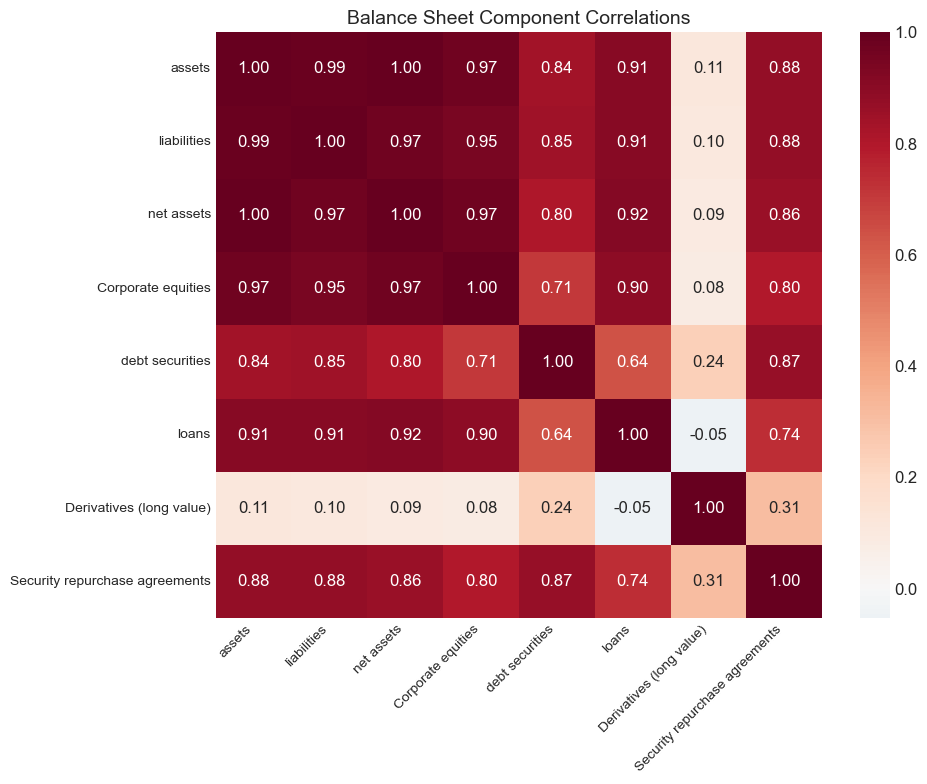

In [11]:
# Correlation matrix of major balance sheet components
from src.visualization.plots import plot_correlation_heatmap

plot_correlation_heatmap(df, save_path="../outputs/figures/correlation_heatmap.png")

## 5. Visualizations

### 5A. Total Assets Over Time

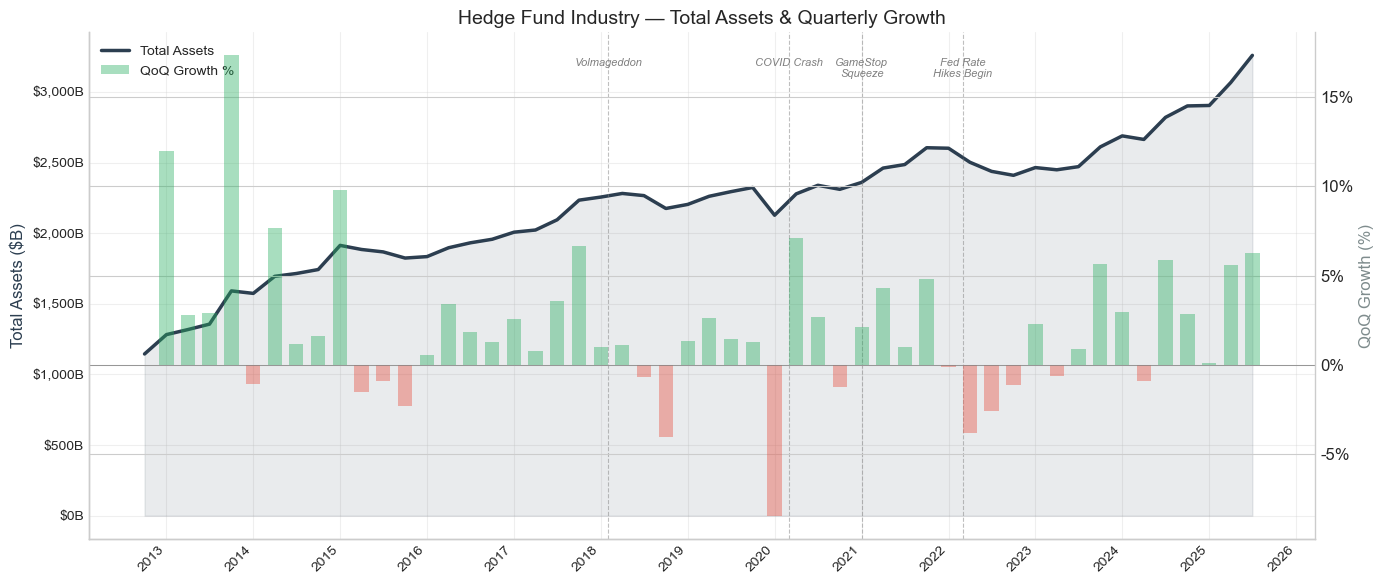

In [12]:
# Import all chart functions from plots.py (formatted + saves to disk)
from src.visualization.plots import (
    add_event_annotations,
    plot_asset_composition,
    plot_balance_sheet_overview,
    plot_borrowing_patterns,
    plot_correlation_heatmap,
    plot_debt_securities,
    plot_derivative_exposure,
    plot_liability_structure,
    plot_total_assets,
)

FIGURES_DIR = "../outputs/figures"

# 5A: Total assets with QoQ growth
plot_total_assets(df, save_path=f"{FIGURES_DIR}/total_assets.png")

### 5B. Asset Composition — What Do Hedge Funds Hold?

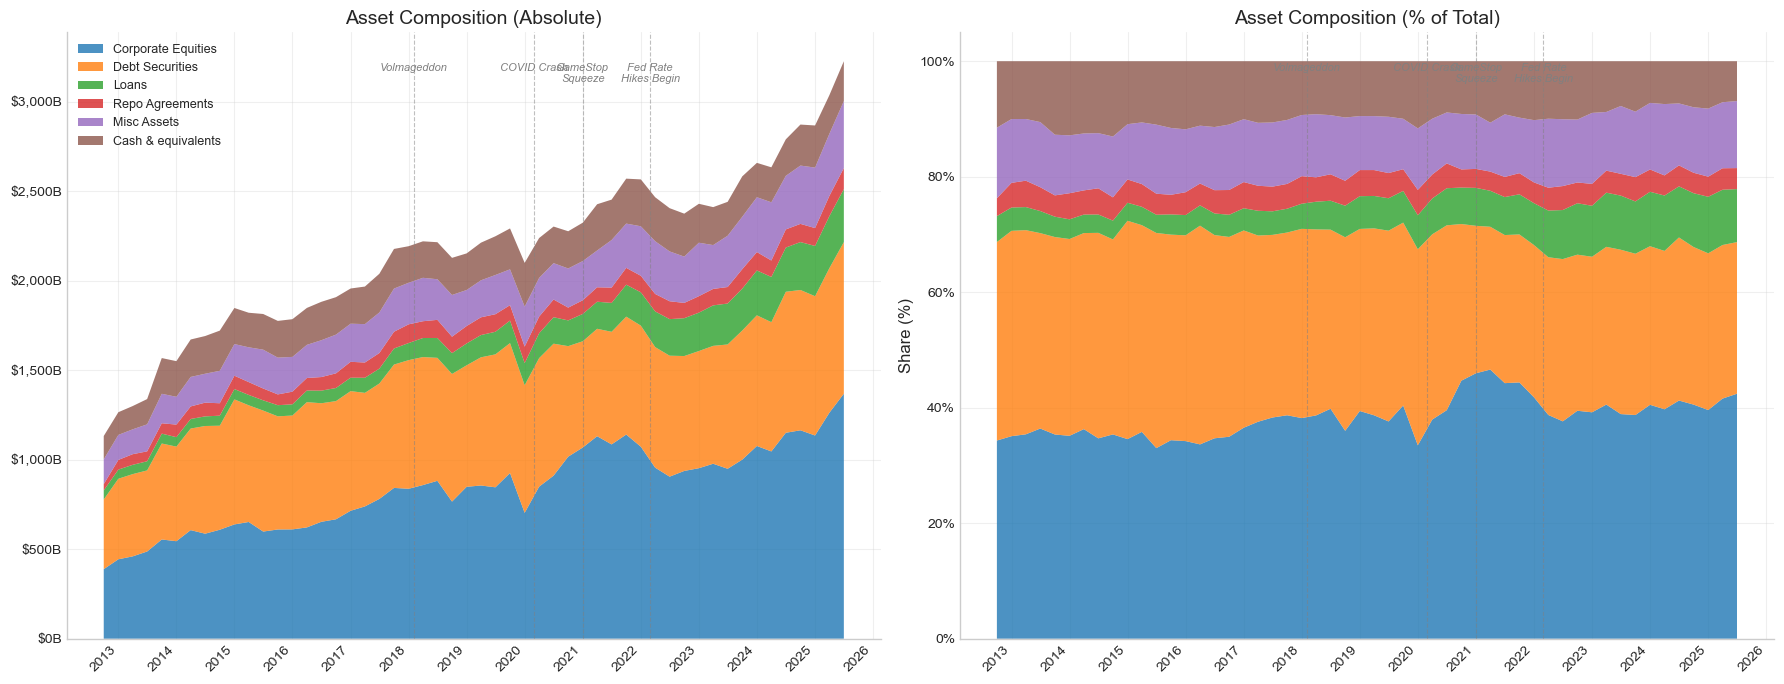

In [13]:
# 5B: Stacked area chart — asset composition
plot_asset_composition(df, save_path=f"{FIGURES_DIR}/asset_composition.png")

### 5C. Debt Securities Deep Dive — Treasury vs. Corporate Bonds

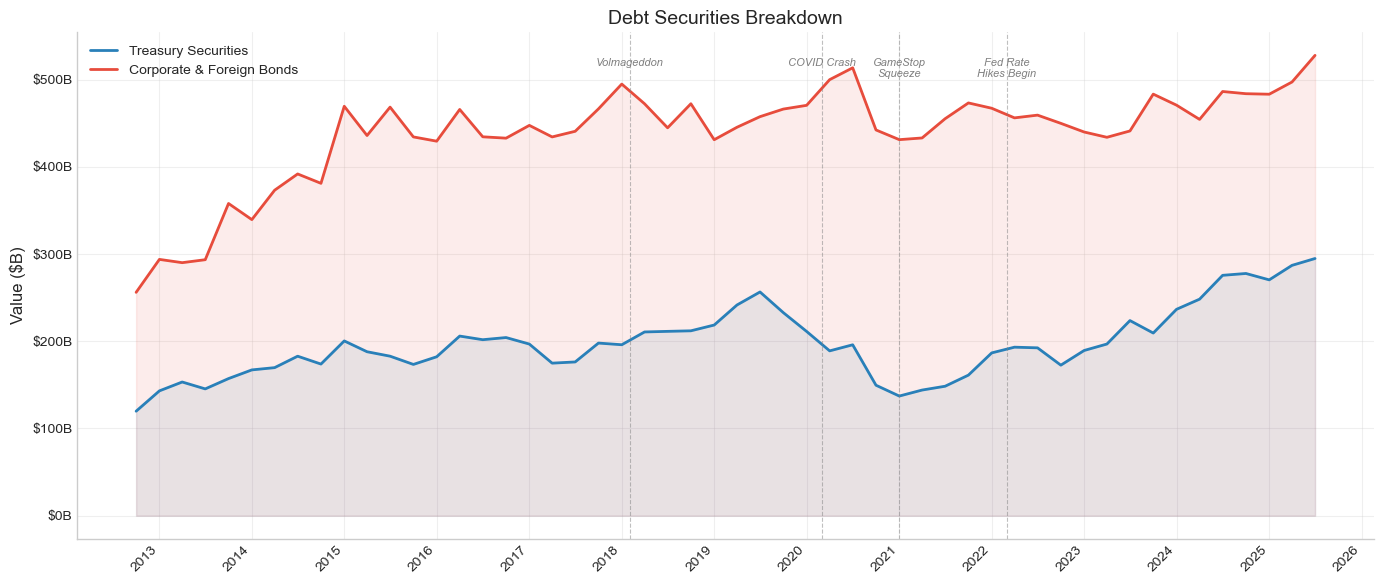

In [14]:
# 5C: Debt securities breakdown
plot_debt_securities(df, save_path=f"{FIGURES_DIR}/debt_securities.png")

### 5D. Liability Structure & Leverage Ratio

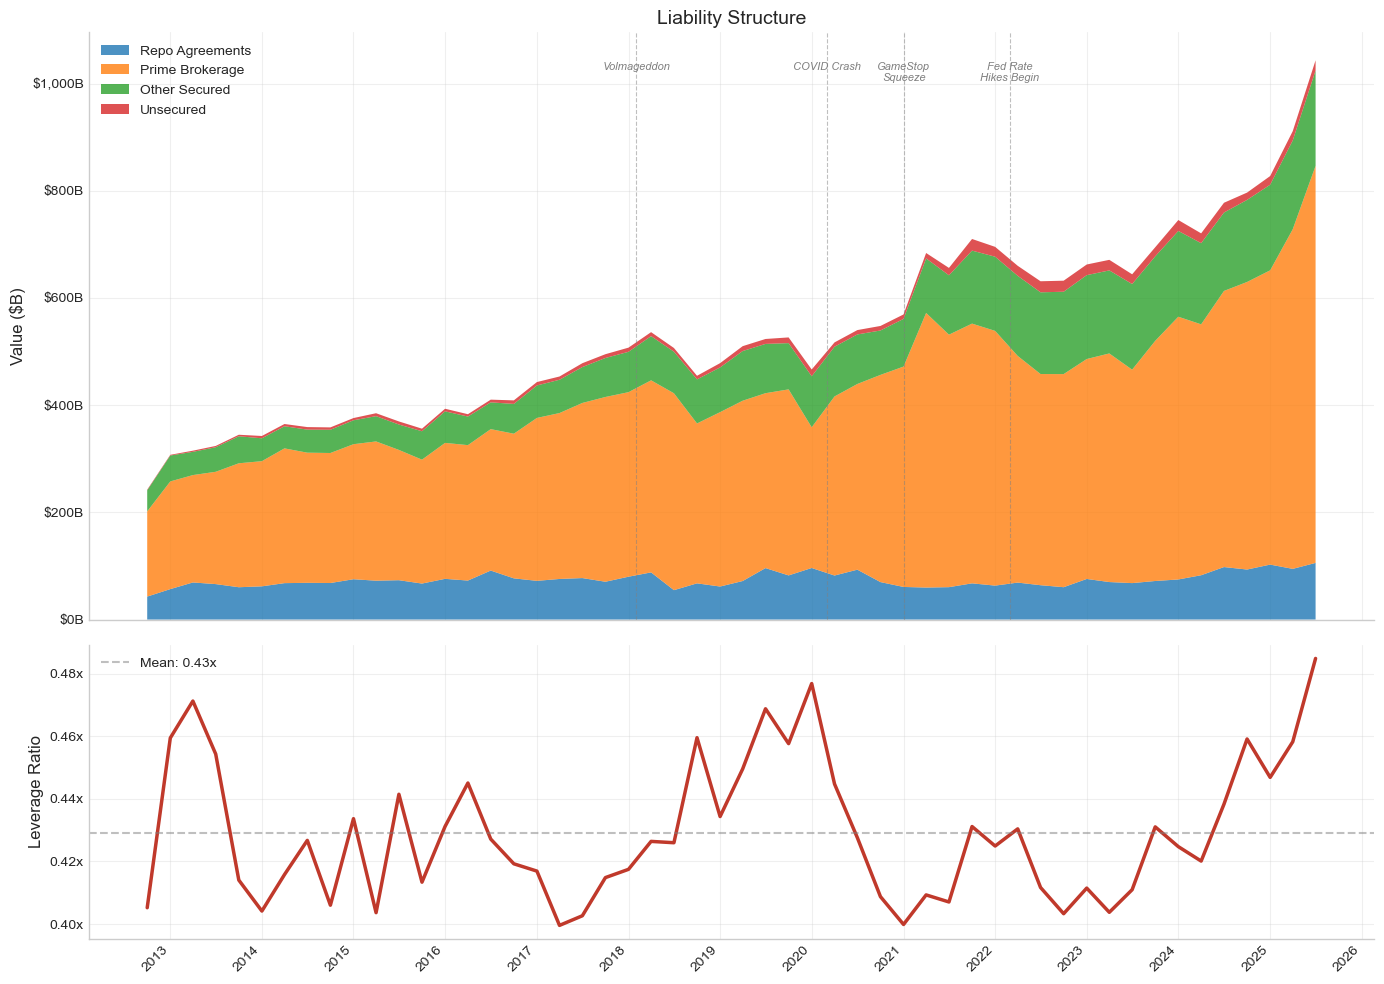

In [15]:
# 5D: Liability structure stacked area + leverage ratio line
plot_liability_structure(df, save_path=f"{FIGURES_DIR}/liability_structure.png")

### 5E. Assets vs. Liabilities vs. Net Assets

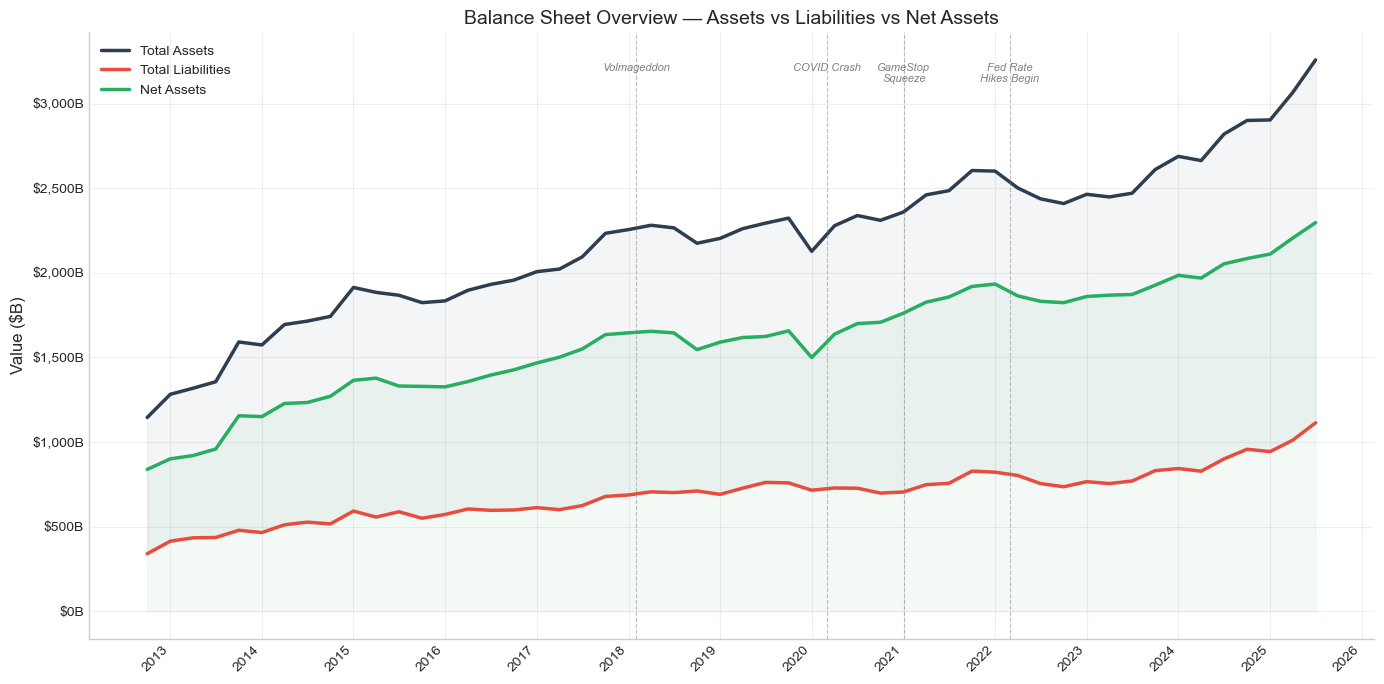

In [16]:
# 5E: Three-line overlay — assets, liabilities, net assets
plot_balance_sheet_overview(df, save_path=f"{FIGURES_DIR}/balance_sheet_overview.png")

### 5F. Derivative Exposure Trends

The Q1 2018 spike in derivatives aligns with "Volmageddon" — the February 2018 VIX blowup that caused massive losses in short-volatility strategies.

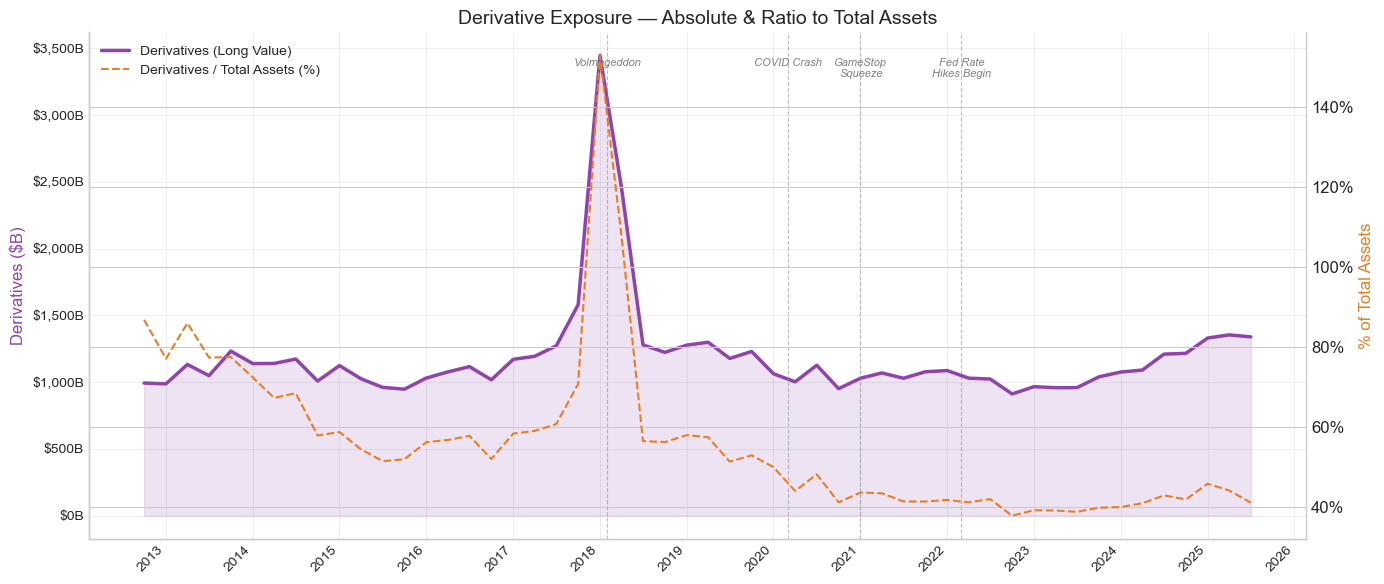

In [17]:
# 5F: Derivative exposure
plot_derivative_exposure(df, save_path=f"{FIGURES_DIR}/derivative_exposure.png")

### 5G. Domestic vs. Foreign Borrowing Patterns

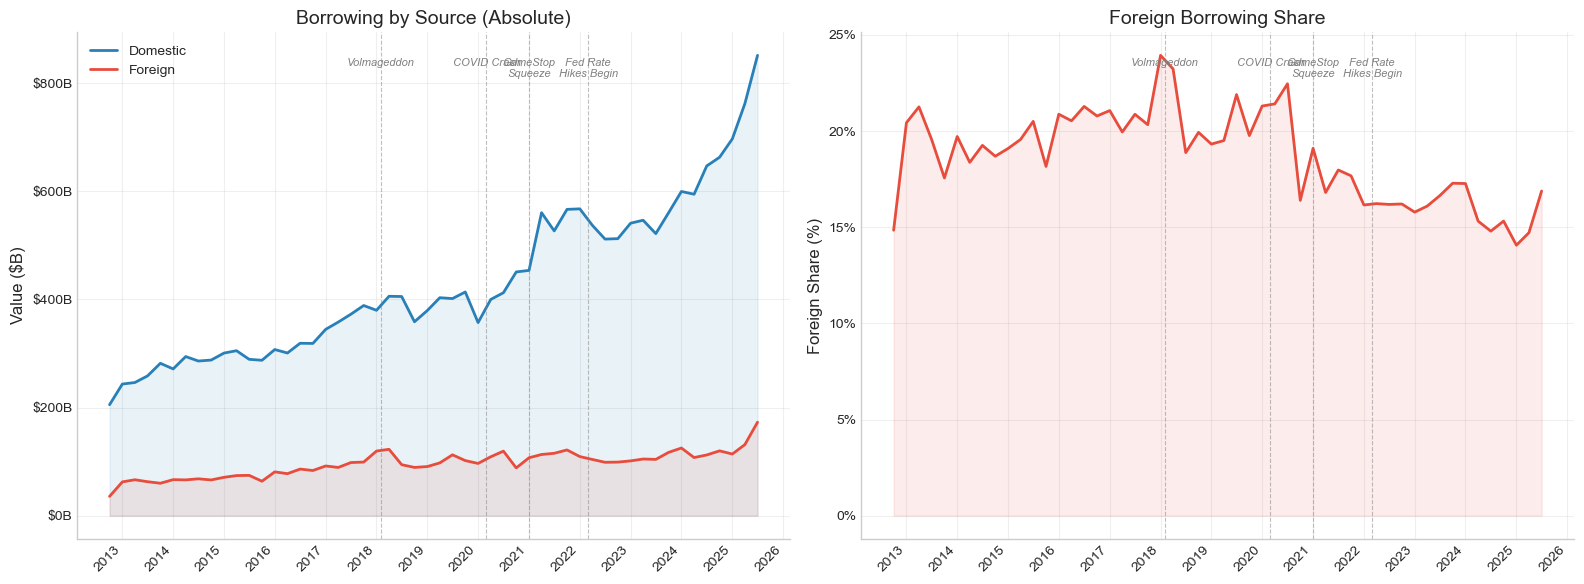

In [18]:
# 5G: Domestic vs foreign borrowing
plot_borrowing_patterns(df, save_path=f"{FIGURES_DIR}/borrowing_patterns.png")

### 5H. Key Ratios Dashboard

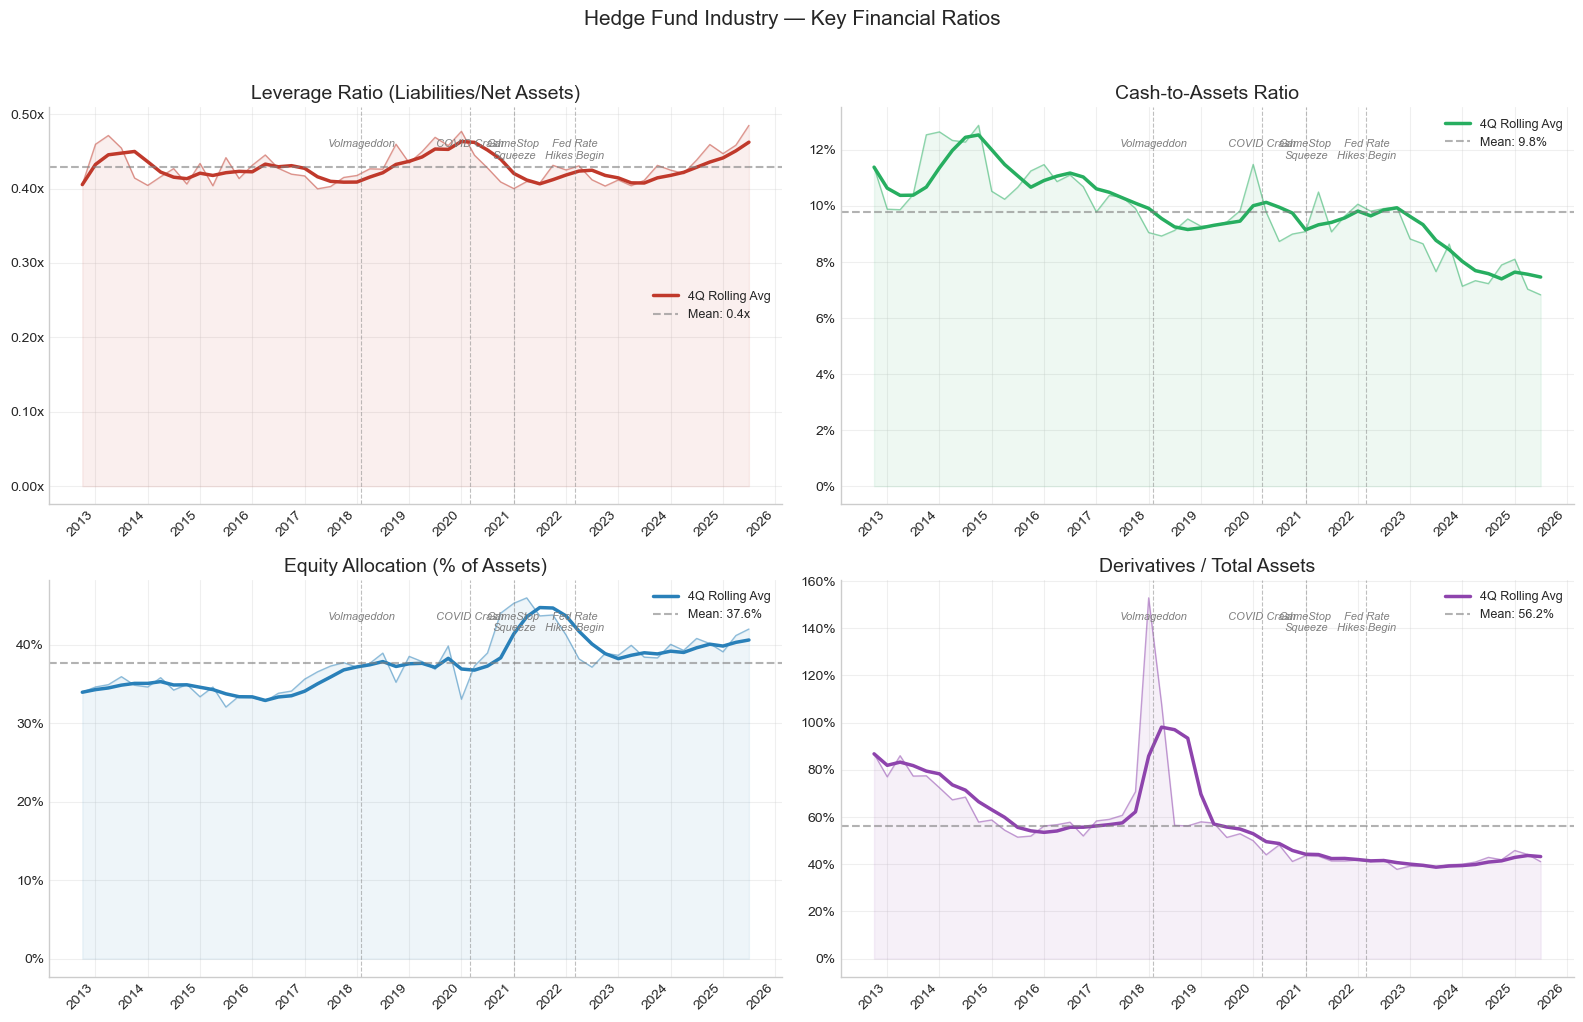

In [19]:
# 5H: Key ratios dashboard — 2x2 grid
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

ratios = [
    ("leverage_ratio", "Leverage Ratio (Liabilities/Net Assets)", "#c0392b", "x"),
    ("cash_to_assets", "Cash-to-Assets Ratio", "#27ae60", "%"),
    ("equity_pct", "Equity Allocation (% of Assets)", "#2980b9", "%"),
    ("derivative_to_assets", "Derivatives / Total Assets", "#8e44ad", "%"),
]

for ax, (col, title, color, fmt) in zip(axes.flat, ratios):
    vals = df[col] * 100 if fmt == "%" else df[col]
    rolling = vals.rolling(4, min_periods=1).mean()

    ax.plot(df.index, vals, linewidth=1, alpha=0.5, color=color)
    ax.plot(df.index, rolling, linewidth=2.5, color=color, label="4Q Rolling Avg")
    ax.fill_between(df.index, vals, alpha=0.08, color=color)

    mean_val = vals.mean()
    suffix = "%" if fmt == "%" else "x"
    ax.axhline(mean_val, color="gray", linestyle="--", alpha=0.6, label=f"Mean: {mean_val:.1f}{suffix}")

    ax.set_title(title)
    ylabel_formatter = fmt_pct if fmt == "%" else fmt_ratio
    polish(ax, ylabel_fmt=ylabel_formatter)
    ax.legend(fontsize=9, framealpha=0.9, edgecolor="gray")
    add_event_annotations(ax, ypos_frac=0.92)

plt.suptitle("Hedge Fund Industry — Key Financial Ratios", fontsize=15, y=1.02)
plt.tight_layout()
plt.show()

### 5I. 13F Holdings — What Did Major Hedge Funds Hold?

> **Note:** 13F filings only disclose **long equity positions**. Short positions, options strategies, and derivatives exposure are not reported. This means 13F data cannot capture the short-side dynamics that drove events like the GameStop squeeze.

13F snapshot: 2021Q1 (17759 equity positions across 8 funds)
  (Puts/calls excluded for clean equity snapshot; 4018 derivative positions omitted)


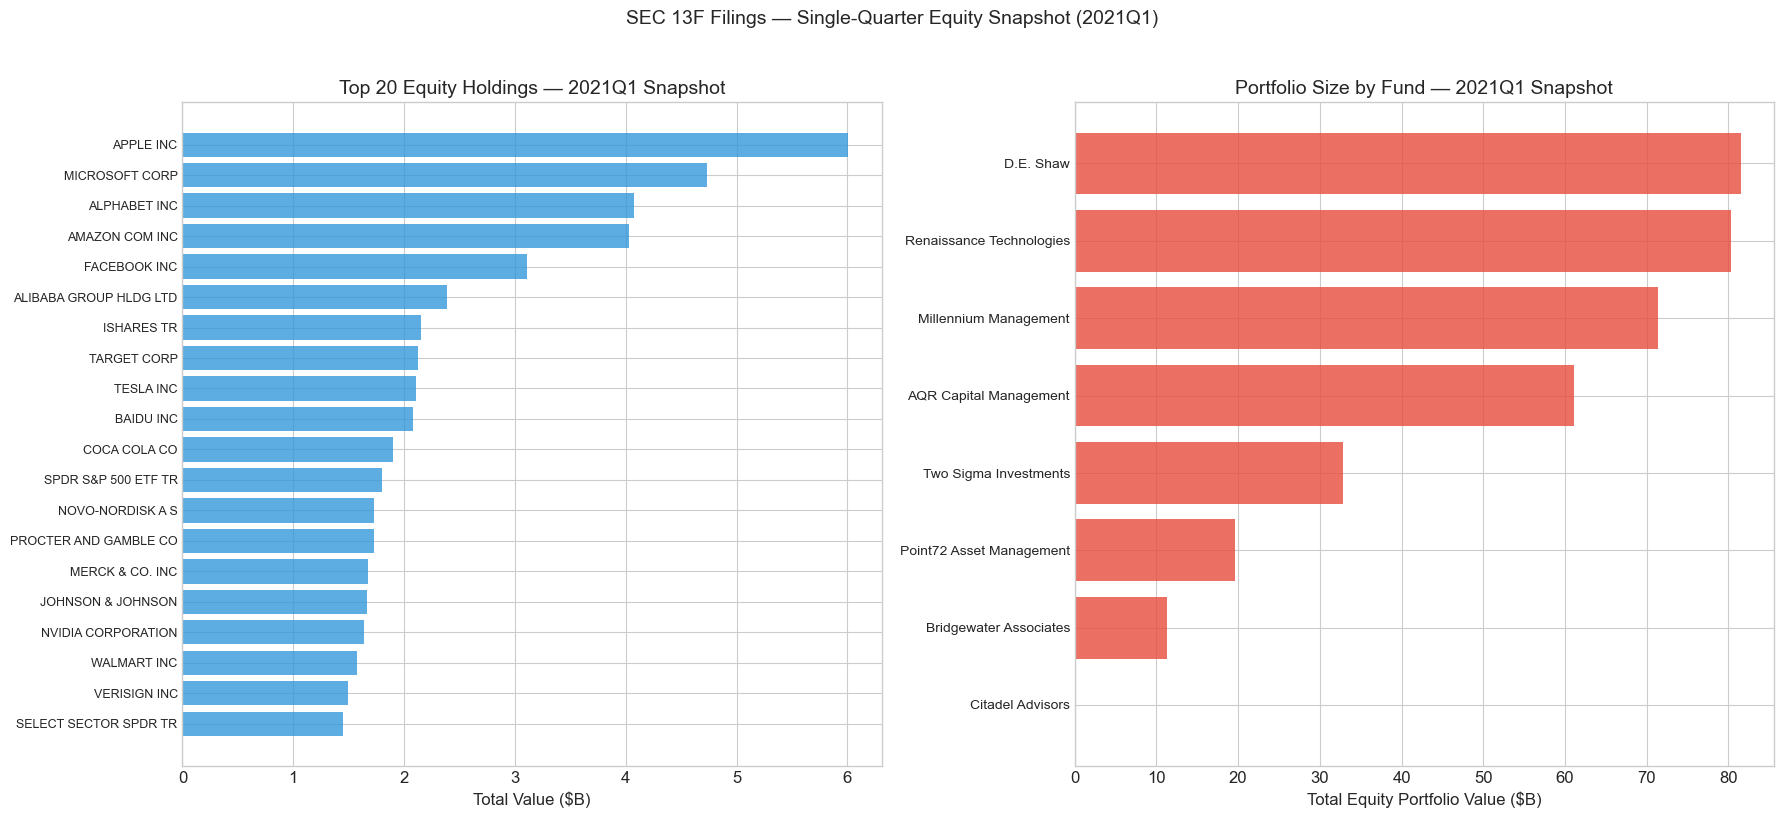


GameStop Holdings Found (all quarters):
                    fund report_quarter filing_date  value_thousands  shares put_call
        Citadel Advisors         2020Q4  2021-02-16            32294 1714100     Call
        Citadel Advisors         2020Q4  2021-02-16            41910 2224500      Put
        Citadel Advisors         2020Q4  2021-02-16             4091  217132      NaN
        Citadel Advisors         2020Q3  2020-11-16             1140  111805      NaN
        Citadel Advisors         2020Q3  2020-11-16            20568 2016500     Call
        Citadel Advisors         2020Q3  2020-11-16            26215 2570100      Put
Renaissance Technologies         2020Q3  2020-11-13             8168  800739      NaN
   Two Sigma Investments         2021Q1  2021-05-17             7422   39100      Put
   Two Sigma Investments         2021Q1  2021-05-17              664    3500     Call
   Two Sigma Investments         2020Q4  2021-02-16             1534   81446      NaN
   Two Sigma 

In [20]:
# 5I: 13F holdings analysis — per-quarter snapshots (not pooled across filings)
if not df_13f.empty and "value_thousands" in df_13f.columns:
    # Derive report quarter from filing date (filings are due ~45 days after quarter-end)
    df_13f["filing_date"] = pd.to_datetime(df_13f["filing_date"])
    if "report_quarter" not in df_13f.columns:
        df_13f["report_quarter"] = df_13f["filing_date"].apply(
            lambda d: (d - pd.DateOffset(months=2)).to_period("Q").strftime("%YQ%q")
        )

    # Use only the LATEST quarter snapshot for portfolio composition
    latest_q = df_13f["report_quarter"].max()
    df_latest = df_13f[df_13f["report_quarter"] == latest_q].copy()
    # Exclude puts/calls for clean equity snapshot (show only common stock)
    df_equity = df_latest[df_latest["put_call"].isna() | (df_latest["put_call"] == "")].copy()

    print(f"13F snapshot: {latest_q} ({len(df_equity)} equity positions across {df_equity['fund'].nunique()} funds)")
    print(
        f"  (Puts/calls excluded for clean equity snapshot; {len(df_latest) - len(df_equity)} derivative positions omitted)"
    )

    # Top holdings by total value in the latest quarter
    top_holdings = df_equity.groupby("issuer")["value_thousands"].sum().sort_values(ascending=False).head(20)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 8))

    # Top 20 most-held stocks (latest quarter only)
    top_holdings_b = top_holdings / 1e6  # Convert thousands to billions
    ax1.barh(range(len(top_holdings_b)), top_holdings_b.values, color="#3498db", alpha=0.8)
    ax1.set_yticks(range(len(top_holdings_b)))
    ax1.set_yticklabels(top_holdings_b.index, fontsize=9)
    ax1.set_xlabel("Total Value ($B)")
    ax1.set_title(f"Top 20 Equity Holdings — {latest_q} Snapshot")
    ax1.invert_yaxis()

    # Holdings by fund (total equity portfolio value, latest quarter)
    fund_totals = df_equity.groupby("fund")["value_thousands"].sum().sort_values(ascending=True) / 1e6
    ax2.barh(range(len(fund_totals)), fund_totals.values, color="#e74c3c", alpha=0.8)
    ax2.set_yticks(range(len(fund_totals)))
    ax2.set_yticklabels(fund_totals.index, fontsize=10)
    ax2.set_xlabel("Total Equity Portfolio Value ($B)")
    ax2.set_title(f"Portfolio Size by Fund — {latest_q} Snapshot")

    plt.suptitle(f"SEC 13F Filings — Single-Quarter Equity Snapshot ({latest_q})", fontsize=14, y=1.02)
    plt.tight_layout()
    plt.show()

    # Check for GameStop (GME) specifically across ALL quarters
    gme = df_13f[df_13f["issuer"].str.contains("GAMESTOP|GME", case=False, na=False)]
    if not gme.empty:
        print("\nGameStop Holdings Found (all quarters):")
        print(
            gme[["fund", "report_quarter", "filing_date", "value_thousands", "shares", "put_call"]].to_string(
                index=False
            )
        )
    else:
        print("\nNo direct GameStop holdings found in 13F data (note: short positions are NOT reported in 13F filings)")
else:
    print("No 13F holdings data available — skipping visualization")

### 5J. CFTC — Leveraged Fund Positioning in Equity Futures

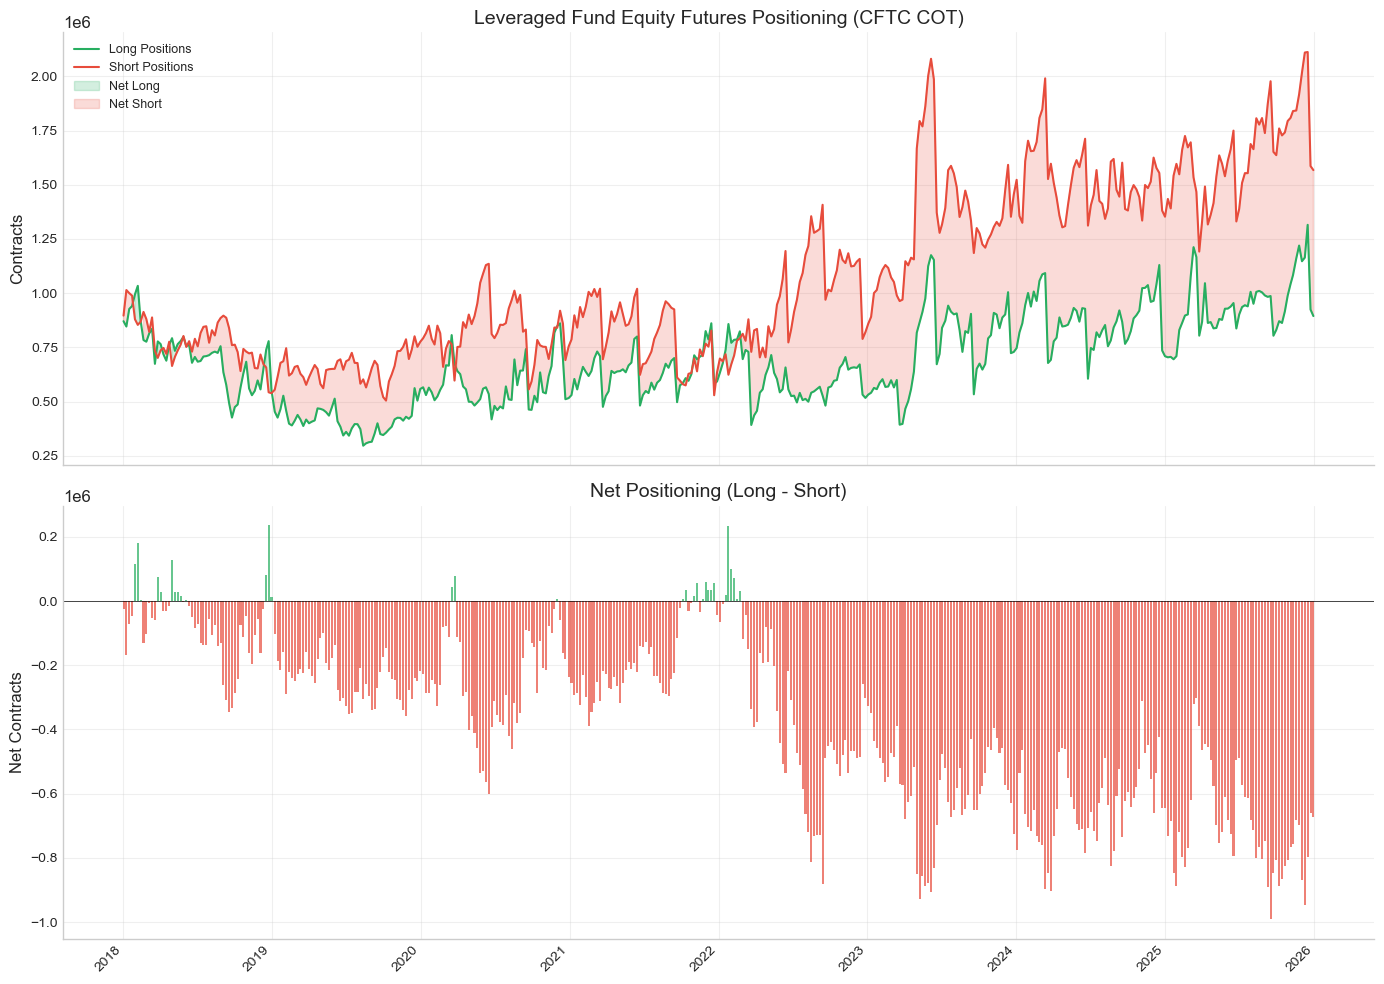

In [21]:
# 5J: CFTC leveraged fund positioning
if not df_cftc.empty and "lev_fund_net" in df_cftc.columns:
    # Aggregate across equity index futures by date
    cftc_agg = (
        df_cftc.groupby("date")
        .agg(
            {
                "lev_fund_long": "sum",
                "lev_fund_short": "sum",
                "lev_fund_net": "sum",
            }
        )
        .sort_index()
    )

    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10), sharex=True)

    # Long vs Short positions
    ax1.plot(cftc_agg.index, cftc_agg["lev_fund_long"], label="Long Positions", color="#27ae60", linewidth=1.5)
    ax1.plot(cftc_agg.index, cftc_agg["lev_fund_short"], label="Short Positions", color="#e74c3c", linewidth=1.5)
    ax1.fill_between(
        cftc_agg.index,
        cftc_agg["lev_fund_long"],
        cftc_agg["lev_fund_short"],
        where=cftc_agg["lev_fund_long"] >= cftc_agg["lev_fund_short"],
        alpha=0.2,
        color="#27ae60",
        label="Net Long",
    )
    ax1.fill_between(
        cftc_agg.index,
        cftc_agg["lev_fund_long"],
        cftc_agg["lev_fund_short"],
        where=cftc_agg["lev_fund_long"] < cftc_agg["lev_fund_short"],
        alpha=0.2,
        color="#e74c3c",
        label="Net Short",
    )
    ax1.set_title("Leveraged Fund Equity Futures Positioning (CFTC COT)")
    ax1.set_ylabel("Contracts")
    ax1.legend(fontsize=9, framealpha=0.9, edgecolor="gray")
    polish(ax1, date_axis=True)

    # Net positioning
    colors = ["#27ae60" if x >= 0 else "#e74c3c" for x in cftc_agg["lev_fund_net"]]
    ax2.bar(cftc_agg.index, cftc_agg["lev_fund_net"], width=5, color=colors, alpha=0.7)
    ax2.axhline(0, color="black", linewidth=0.5)
    ax2.set_title("Net Positioning (Long - Short)")
    ax2.set_ylabel("Net Contracts")
    polish(ax2, date_axis=True)

    plt.tight_layout()
    plt.show()
else:
    print("No CFTC data available — skipping visualization")

### 5K. VIX vs. Hedge Fund Leverage — Does Volatility Drive Deleveraging?

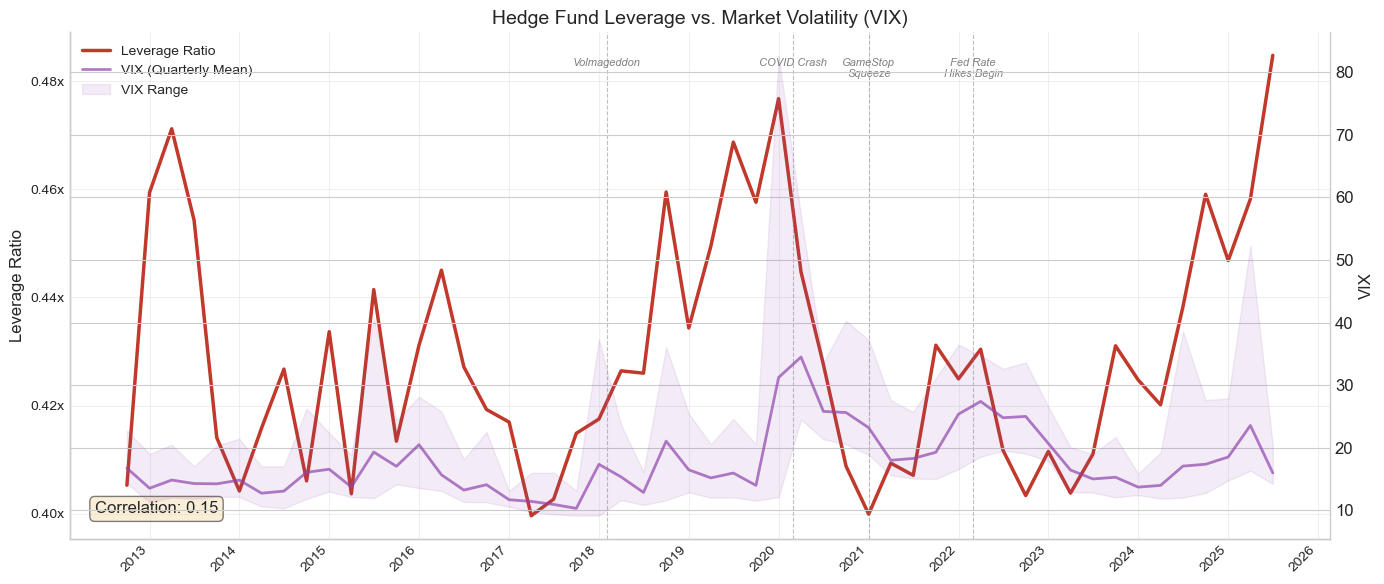

In [22]:
# 5K: VIX vs leverage ratio
if "VIX_mean" in df_merged.columns and df_merged["VIX_mean"].notna().any():
    fig, ax1 = plt.subplots(figsize=(14, 6))

    ax1.plot(df_merged.index, df_merged["leverage_ratio"], linewidth=2.5, color="#c0392b", label="Leverage Ratio")
    ax1.set_ylabel("Leverage Ratio")

    ax2 = ax1.twinx()
    ax2.plot(
        df_merged.index, df_merged["VIX_mean"], linewidth=2, color="#8e44ad", alpha=0.7, label="VIX (Quarterly Mean)"
    )
    ax2.fill_between(
        df_merged.index, df_merged["VIX_min"], df_merged["VIX_max"], alpha=0.1, color="#8e44ad", label="VIX Range"
    )
    ax2.set_ylabel("VIX")

    # Correlation
    valid = df_merged[["leverage_ratio", "VIX_mean"]].dropna()
    corr = valid["leverage_ratio"].corr(valid["VIX_mean"])
    ax1.annotate(
        f"Correlation: {corr:.2f}",
        xy=(0.02, 0.05),
        xycoords="axes fraction",
        fontsize=12,
        bbox=dict(boxstyle="round", facecolor="wheat", alpha=0.5),
    )

    ax1.set_title("Hedge Fund Leverage vs. Market Volatility (VIX)")
    add_event_annotations(ax1)
    polish(ax1, ylabel_fmt=fmt_ratio)
    ax2.spines[["top"]].set_visible(False)
    merge_legends(ax1, ax2)
    plt.tight_layout()
    plt.show()
else:
    print("No VIX data available for this visualization")

### 5L. Form PF — Fund-Level Leverage & Strategy Allocation

SEC Form PF (Private Fund reporting) provides fund-level data that the aggregate Z.1 balance sheet cannot: **Gross Asset Value (GAV)**, **Net Asset Value (NAV)**, strategy breakdowns, and liquidity profiles. Quarterly since 2013, covering ~1,500 large hedge funds.

The GAV/NAV ratio is a true leverage proxy — a ratio of 2.0x means the fund controls $2 in gross assets for every $1 of investor equity.

Form PF hedge fund data: 49 quarters
  GAV range: $4,780B – $12,590B
  Latest GAV/NAV ratio: 2.32x


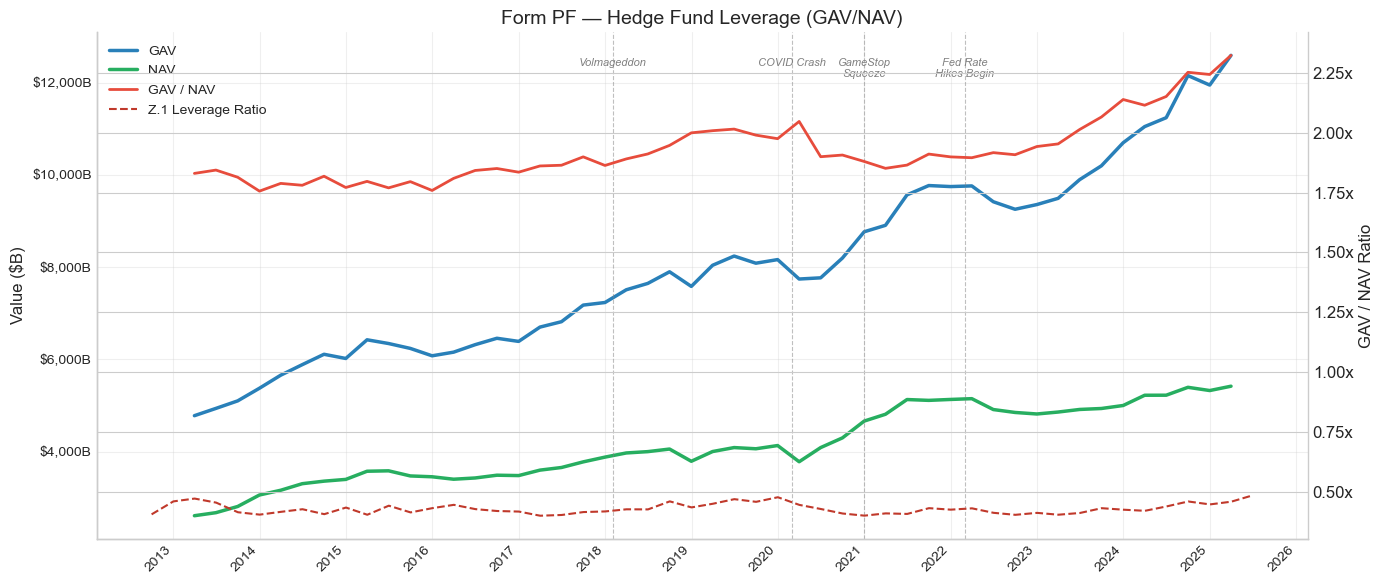

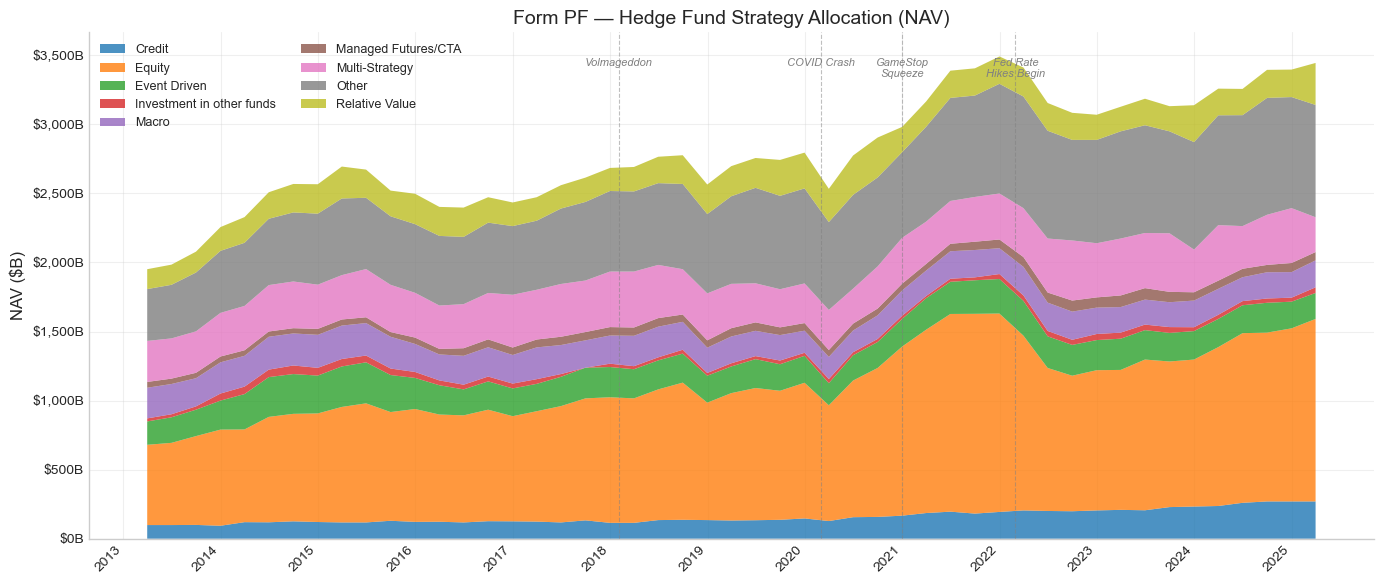

In [23]:
# 5L: Form PF leverage and strategy allocation
from src.visualization.plots import plot_form_pf_leverage, plot_strategy_allocation

PROCESSED_DIR = os.path.join("..", "data", "processed")

# Load Form PF GAV/NAV data
pf_gav = pd.read_csv(os.path.join(PROCESSED_DIR, "form_pf_gav_nav.csv"))
pf_hf = pf_gav[pf_gav["fund_type"] == "Hedge Fund"].copy()
print(f"Form PF hedge fund data: {len(pf_hf)} quarters")
print(f"  GAV range: ${pf_hf['gav'].min():,.0f}B – ${pf_hf['gav'].max():,.0f}B")
print(f"  Latest GAV/NAV ratio: {pf_hf['gav'].iloc[-1] / pf_hf['nav'].iloc[-1]:.2f}x")

# Plot leverage with Z.1 overlay
plot_form_pf_leverage(pf_hf, z1_df=df, save_path="../outputs/figures/form_pf_leverage.png")

# Load and plot strategy allocation
pf_strat = pd.read_csv(os.path.join(PROCESSED_DIR, "form_pf_strategy.csv"))
plot_strategy_allocation(pf_strat, save_path="../outputs/figures/strategy_allocation.png")

### 5M. CFTC Weekly Swaps — OTC Derivatives Market

The CFTC publishes weekly reports on OTC swap notional outstanding by asset class (interest rate, credit, FX, equity, commodity) and clearing status. This reveals the **scale of off-balance-sheet derivatives** that Z.1 only partially captures through "Derivatives (long value)."

CFTC swaps data: 605 weekly observations, 2012-12-07 to 2026-02-20


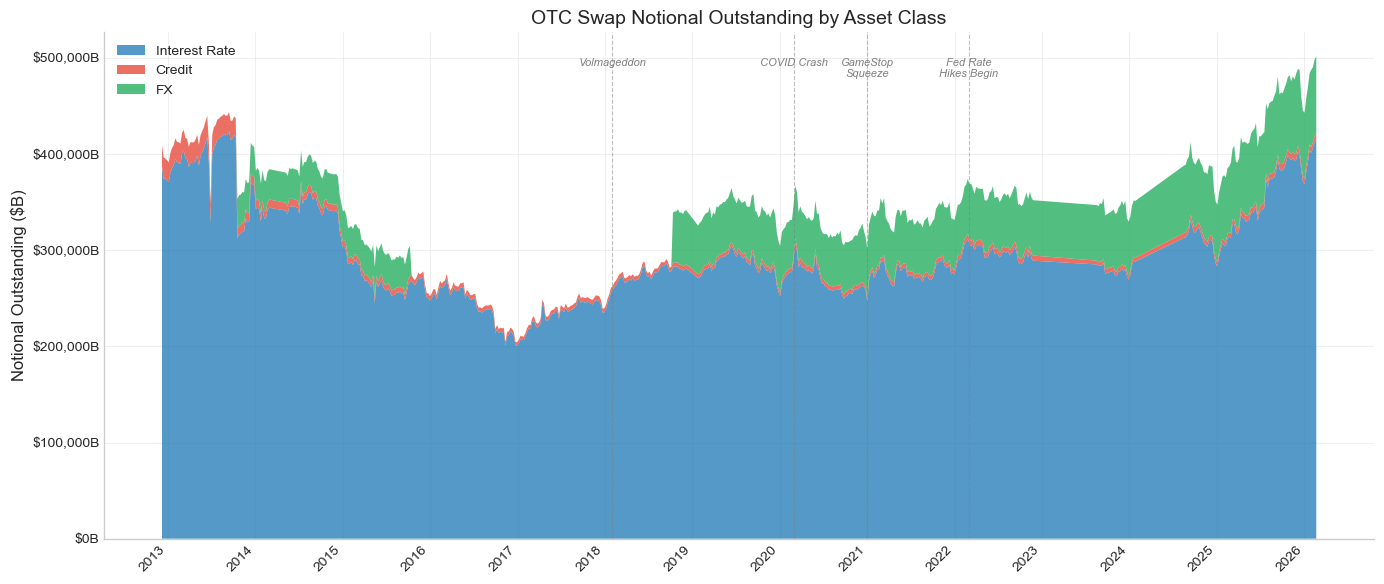

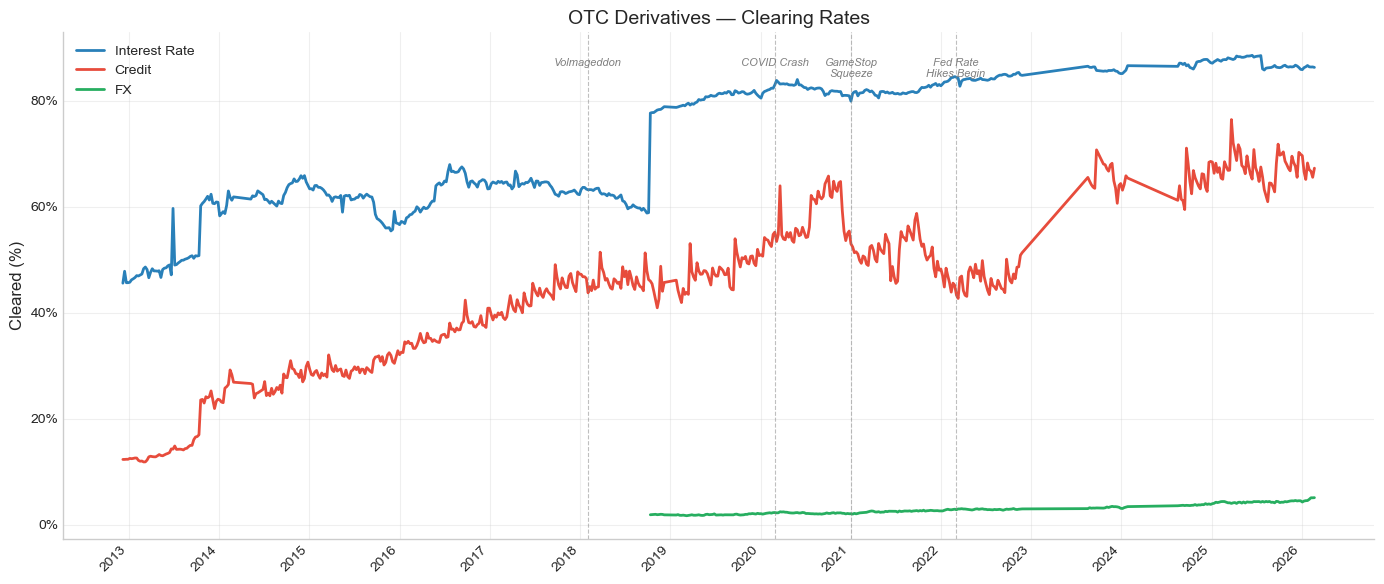

In [24]:
# 5M: CFTC swaps notional and clearing rates
from src.visualization.plots import plot_clearing_rate, plot_swaps_notional

swaps_df = pd.read_csv(os.path.join(PROCESSED_DIR, "swaps_weekly.csv"))
swaps_df["date"] = pd.to_datetime(swaps_df["date"])
print(
    f"CFTC swaps data: {len(swaps_df)} weekly observations, {swaps_df['date'].min().date()} to {swaps_df['date'].max().date()}"
)

# Notional outstanding by asset class
plot_swaps_notional(swaps_df, save_path="../outputs/figures/swaps_notional.png")

# Clearing rates over time
plot_clearing_rate(swaps_df, save_path="../outputs/figures/clearing_rate.png")

### 5N. FCM Broker Financials — Capital Adequacy & Concentration

Futures Commission Merchants (FCMs) are the brokers that clear hedge fund derivatives trades. Their monthly CFTC financial reports reveal **capital adequacy**, **customer segregated funds**, and **market concentration** — the plumbing that breaks during crises.

FCM industry data: 49 monthly observations, 2022-01-31 to 2026-01-31


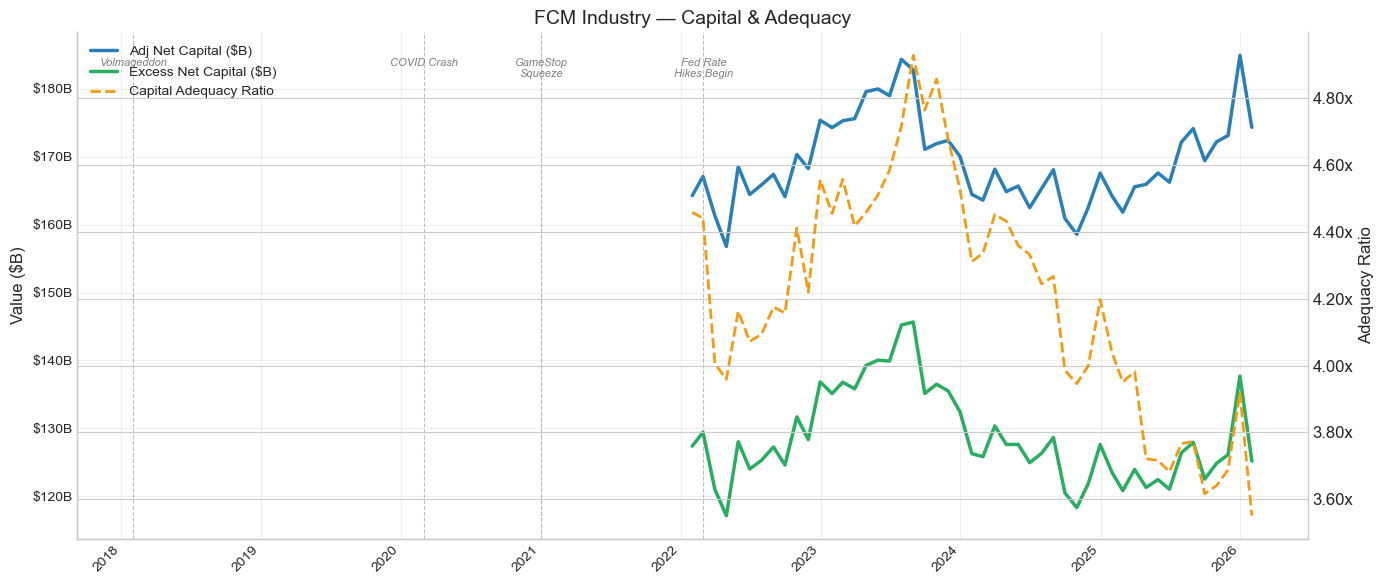

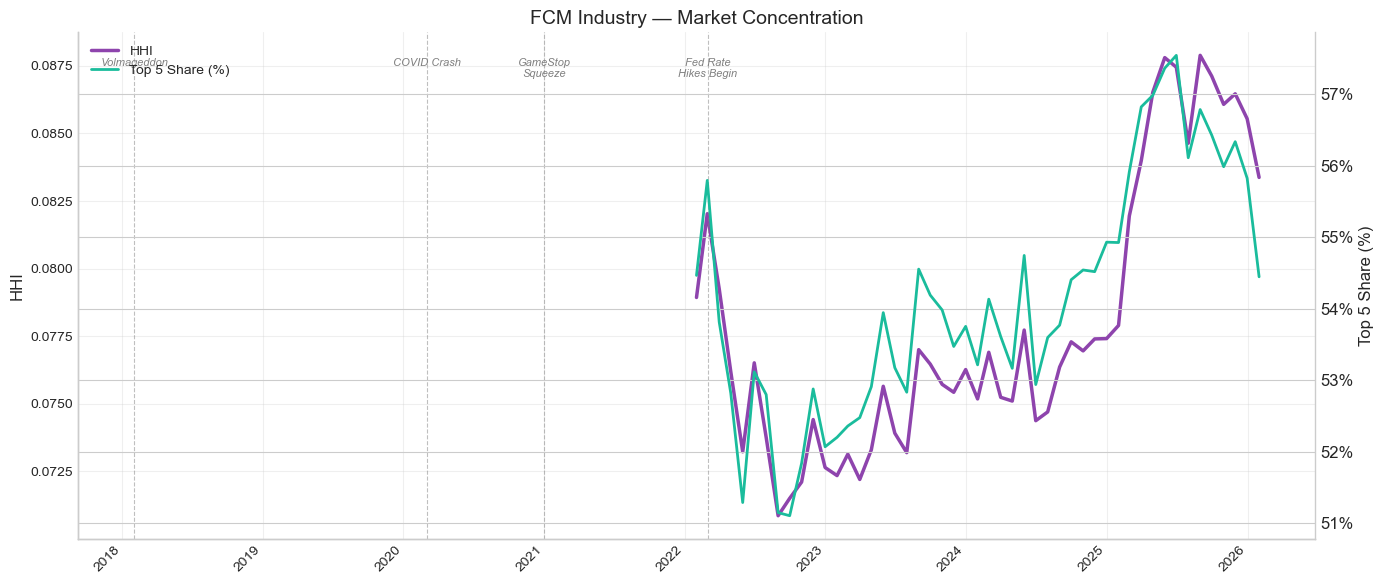

In [25]:
# 5N: FCM capital and concentration
from src.visualization.plots import plot_fcm_capital, plot_fcm_concentration

fcm_industry = pd.read_csv(os.path.join(PROCESSED_DIR, "fcm_monthly_industry.csv"))
date_col = "date" if "date" in fcm_industry.columns else "as_of_date"
fcm_industry[date_col] = pd.to_datetime(fcm_industry[date_col])
print(
    f"FCM industry data: {len(fcm_industry)} monthly observations, {fcm_industry[date_col].min().date()} to {fcm_industry[date_col].max().date()}"
)

plot_fcm_capital(fcm_industry, save_path="../outputs/figures/fcm_capital.png")

# Concentration (HHI and top-5 share)
fcm_conc = pd.read_csv(os.path.join(PROCESSED_DIR, "fcm_concentration.csv"))
plot_fcm_concentration(fcm_conc, save_path="../outputs/figures/fcm_concentration.png")

### 5O. DTCC Swap Repository — Trade-Level OTC Data

The DTCC's Swap Data Repository captures **individual OTC derivative transactions** across 5 asset classes (Rates, Credits, Equities, Forex, Commodities). This trade-level data reveals clearing rates, prime brokerage involvement, and block trade activity that aggregate reports cannot show.

DTCC quarterly data: 25 rows across 5 asset classes
  Quarters covered: ['2025Q1', '2025Q2', '2025Q3', '2025Q4', '2026Q1']


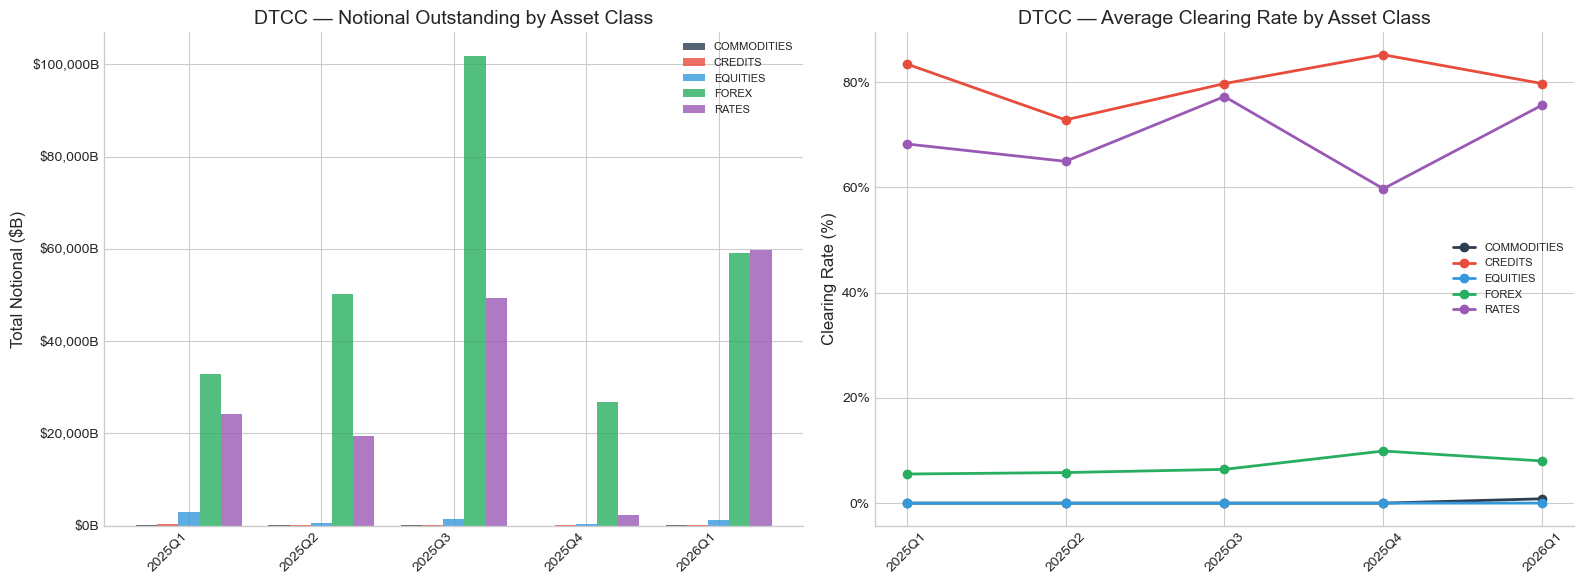


Prime Brokerage Involvement (avg across asset classes):
  COMMODITIES    : 1.0% of trades
  CREDITS        : 0.0% of trades
  EQUITIES       : 0.0% of trades
  FOREX          : 41.0% of trades
  RATES          : 0.3% of trades


In [26]:
# 5O: DTCC trade-level OTC data — quarterly summary
dtcc_q = pd.read_csv(os.path.join(PROCESSED_DIR, "dtcc_quarterly.csv"))
print(f"DTCC quarterly data: {len(dtcc_q)} rows across {dtcc_q['asset_class'].nunique()} asset classes")
print(f"  Quarters covered: {sorted(dtcc_q['quarter'].unique())}")

# Show key metrics by asset class
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Grouped bar chart — notional by asset class per quarter
quarters = sorted(dtcc_q["quarter"].unique())
asset_classes = sorted(dtcc_q["asset_class"].unique())
colors = ["#2c3e50", "#e74c3c", "#3498db", "#27ae60", "#9b59b6"]
n_classes = len(asset_classes)
x = np.arange(len(quarters))
bar_width = 0.8 / n_classes

# Use the correct column name from the parsed data
notional_col = (
    "quarter_end_total_notional_bn" if "quarter_end_total_notional_bn" in dtcc_q.columns else "total_notional_bn"
)
cleared_col = "quarter_end_cleared_pct" if "quarter_end_cleared_pct" in dtcc_q.columns else "avg_cleared_pct"
pb_col = "quarter_end_pb_pct" if "quarter_end_pb_pct" in dtcc_q.columns else "avg_pb_pct"

for i, ac in enumerate(asset_classes):
    ac_data = dtcc_q[dtcc_q["asset_class"] == ac].set_index("quarter").reindex(quarters)
    ax1.bar(
        x + i * bar_width - 0.4 + bar_width / 2,
        ac_data[notional_col],
        width=bar_width,
        color=colors[i % len(colors)],
        alpha=0.8,
        label=ac,
    )

ax1.set_xticks(x)
ax1.set_xticklabels(quarters, fontsize=9, rotation=45, ha="right")
ax1.set_ylabel("Total Notional ($B)")
ax1.set_title("DTCC — Notional Outstanding by Asset Class")
ax1.legend(fontsize=8, framealpha=0.9, edgecolor="gray")
ax1.spines[["top", "right"]].set_visible(False)
ax1.yaxis.set_major_formatter(fmt_billions)
ax1.tick_params(labelsize=10)

# Clearing rates by asset class
for i, ac in enumerate(asset_classes):
    ac_data = dtcc_q[dtcc_q["asset_class"] == ac].sort_values("quarter")
    ax2.plot(
        ac_data["quarter"],
        ac_data[cleared_col] * 100,
        "o-",
        color=colors[i % len(colors)],
        label=ac,
        linewidth=2,
        markersize=6,
    )
ax2.set_ylabel("Clearing Rate (%)")
ax2.set_title("DTCC — Average Clearing Rate by Asset Class")
ax2.legend(fontsize=8, framealpha=0.9, edgecolor="gray")
ax2.spines[["top", "right"]].set_visible(False)
ax2.yaxis.set_major_formatter(fmt_pct)
ax2.tick_params(axis="x", labelsize=9, rotation=45)
ax2.tick_params(labelsize=10)

plt.tight_layout()
plt.savefig("../outputs/figures/dtcc_summary.png", dpi=150, bbox_inches="tight")
plt.show()

# Prime brokerage involvement
print("\nPrime Brokerage Involvement (avg across asset classes):")
for ac in sorted(asset_classes):
    ac_data = dtcc_q[dtcc_q["asset_class"] == ac]
    print(f"  {ac:15s}: {ac_data[pb_col].mean():.1%} of trades")

### 5O. Cross-Source Reconciliation — Z.1 vs Form PF Leverage

This is the chart that justifies combining multiple data sources. The Fed's Z.1 **leverage ratio** (liabilities / net assets) and Form PF's **GAV/NAV ratio** (gross assets / net assets) measure leverage through different lenses — one from the liability side, one from the asset side. When they diverge, it reveals off-balance-sheet exposure or measurement gaps.

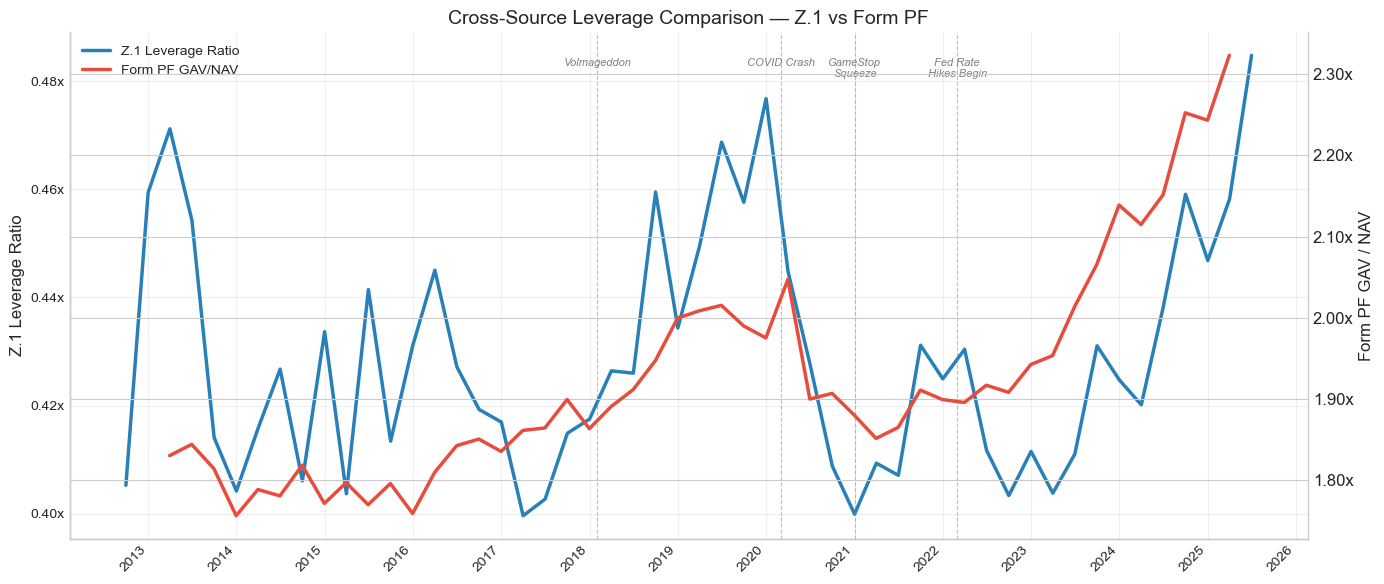


Cross-source overlap: 49 quarters where both Z.1 and Form PF have data
  Z.1 coverage:     2012Q4 to 2025Q3
  Form PF coverage: 2013Q1 to 2025Q1


In [27]:
# 5O: Cross-source leverage comparison — the flagship chart
from src.visualization.plots import plot_cross_source_leverage

plot_cross_source_leverage(df, pf_hf, save_path="../outputs/figures/cross_source_leverage.png")

# Print coverage overlap
pf_quarters = pd.to_datetime(pf_hf["quarter"]).dt.to_period("Q")
z1_quarters = df.index.to_period("Q")
overlap = pf_quarters.isin(z1_quarters).sum()
print(f"\nCross-source overlap: {overlap} quarters where both Z.1 and Form PF have data")
print(f"  Z.1 coverage:     {z1_quarters.min()} to {z1_quarters.max()}")
print(f"  Form PF coverage: {pf_quarters.min()} to {pf_quarters.max()}")

## 6. Sidebar: GameStop Event in Aggregate Data

> **Important caveats:** The analysis below uses **industry-aggregate** Z.1 data (~1,000+ funds). Individual fund impacts (e.g., Melvin Capital's ~53% January 2021 loss) are diluted across the sector. Short positions — central to the GameStop story — are **not captured** in either 13F filings or Z.1 balance sheets. This section shows what aggregate data can and cannot reveal about a fund-level event.

In January 2021, retail investors on r/WallStreetBets triggered a massive short squeeze on GameStop (GME). The before/after comparison below shows industry-wide metrics, not individual fund exposure.

NOTE: These are industry aggregates across ~1,000+ funds.
Individual fund impacts (e.g., Melvin Capital) are diluted.
Short positions are NOT captured in Z.1 or 13F data.



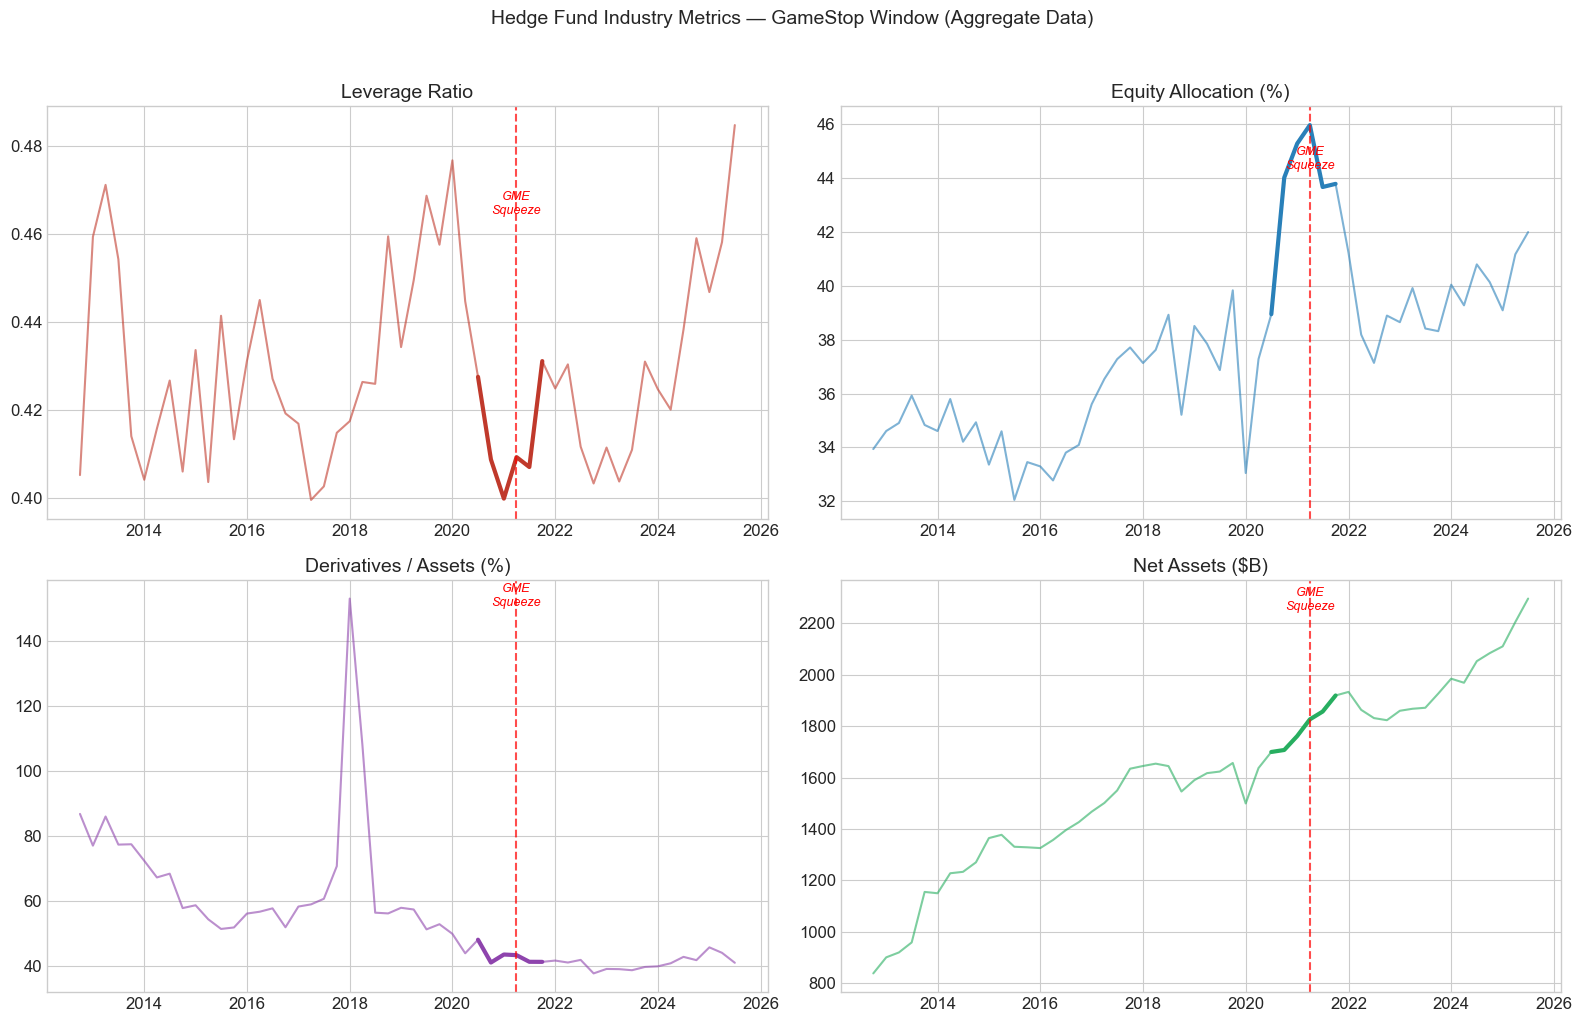


BEFORE vs AFTER GameStop (4-Quarter Averages, Industry Aggregate)
  Leverage Ratio           : 0.42x → 0.42x (-0.5%)
  Equity Allocation        : 41.4% → 43.7%  (+5.5%)
  Derivatives/Assets       : 44.3% → 42.0%  (-5.1%)
  Net Assets ($B)          : $1,701B → $1,884B (+10.7%)


In [28]:
# GameStop window analysis — before and after Q1 2021
print("NOTE: These are industry aggregates across ~1,000+ funds.")
print("Individual fund impacts (e.g., Melvin Capital) are diluted.")
print("Short positions are NOT captured in Z.1 or 13F data.\n")

gme_date = pd.Timestamp("2021-03-31")

# Check if we have data around the GameStop event
if gme_date in df.index or df.index.max() >= gme_date:
    # Find the closest quarters
    pre_gme = df.loc[:gme_date].iloc[-4:]  # 4 quarters before
    post_gme = df.loc[gme_date:].iloc[:4]  # 4 quarters after (including Q1 2021)

    fig, axes = plt.subplots(2, 2, figsize=(16, 10))

    metrics = [
        ("leverage_ratio", "Leverage Ratio", "#c0392b"),
        ("equity_pct", "Equity Allocation (%)", "#2980b9"),
        ("derivative_to_assets", "Derivatives / Assets (%)", "#8e44ad"),
        ("Total net assets", "Net Assets ($B)", "#27ae60"),
    ]

    for ax, (col, title, color) in zip(axes.flat, metrics):
        # Full time series
        vals = df[col] * 100 if "pct" in col or "to_assets" in col else df[col]
        ax.plot(df.index, vals, linewidth=1.5, color=color, alpha=0.6)

        # Highlight GameStop window
        window_start = pd.Timestamp("2020-06-30")
        window_end = pd.Timestamp("2021-12-31")
        window = df.loc[window_start:window_end]
        window_vals = window[col] * 100 if "pct" in col or "to_assets" in col else window[col]
        ax.plot(window.index, window_vals, linewidth=3, color=color)

        ax.axvline(gme_date, color="red", linestyle="--", linewidth=1.5, alpha=0.7)
        ax.text(gme_date, ax.get_ylim()[1] * 0.95, "GME\nSqueeze", ha="center", fontsize=9, color="red", style="italic")
        ax.set_title(title)

    plt.suptitle("Hedge Fund Industry Metrics — GameStop Window (Aggregate Data)", fontsize=14, y=1.02)
    plt.tight_layout()
    plt.show()

    # Print before/after comparison
    if len(pre_gme) > 0 and len(post_gme) > 0:
        print("\n" + "=" * 60)
        print("BEFORE vs AFTER GameStop (4-Quarter Averages, Industry Aggregate)")
        print("=" * 60)
        for col, label in [
            ("leverage_ratio", "Leverage Ratio"),
            ("equity_pct", "Equity Allocation"),
            ("derivative_to_assets", "Derivatives/Assets"),
            ("Total net assets", "Net Assets ($B)"),
        ]:
            before = pre_gme[col].mean()
            after = post_gme[col].mean()
            pct_change = (after - before) / before * 100
            if "pct" in col or "to_assets" in col:
                print(f"  {label:25s}: {before:.1%} → {after:.1%}  ({pct_change:+.1f}%)")
            elif "ratio" in col:
                print(f"  {label:25s}: {before:.2f}x → {after:.2f}x ({pct_change:+.1f}%)")
            else:
                print(f"  {label:25s}: ${before:,.0f}B → ${after:,.0f}B ({pct_change:+.1f}%)")
else:
    print(f"Data ends at {df.index.max().date()} — does not cover GameStop (Q1 2021)")
    print("Showing the trajectory leading into the event instead...")

    # Show last 8 quarters of available data
    recent = df.iloc[-8:]
    fig, ax = plt.subplots(figsize=(14, 6))
    ax.plot(recent.index, recent["leverage_ratio"], "o-", linewidth=2, markersize=8, color="#c0392b")
    for idx, val in recent["leverage_ratio"].items():
        ax.annotate(f"{val:.3f}", (idx, val), textcoords="offset points", xytext=(0, 10), ha="center", fontsize=9)
    ax.set_title("Leverage Ratio — Trajectory Leading into GameStop (Jan 2021)")
    ax.set_ylabel("Leverage Ratio")
    plt.tight_layout()
    plt.show()

## 7. Statistical Analysis

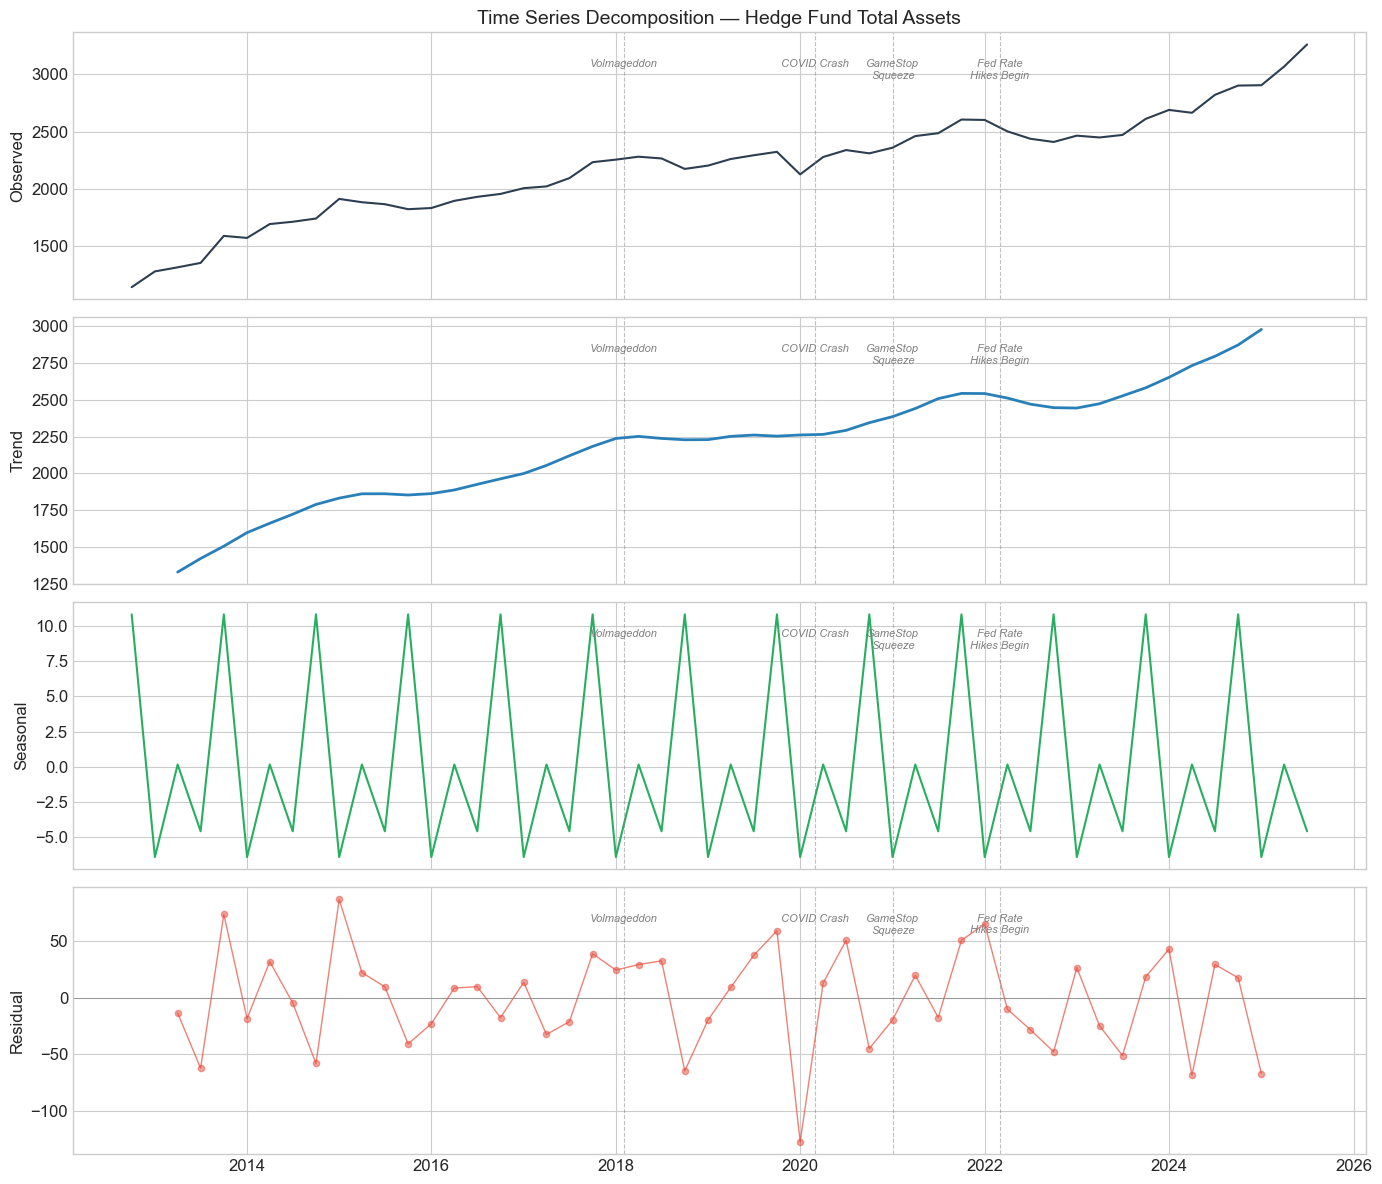

In [29]:
# Time series decomposition of total assets
from statsmodels.tsa.seasonal import seasonal_decompose

if len(df) >= 8:
    total_assets_clean = df["Total assets"].dropna()
    decomp = seasonal_decompose(total_assets_clean, model="additive", period=4)

    fig, axes = plt.subplots(4, 1, figsize=(14, 12), sharex=True)

    axes[0].plot(decomp.observed, color="#2c3e50", linewidth=1.5)
    axes[0].set_ylabel("Observed")
    axes[0].set_title("Time Series Decomposition — Hedge Fund Total Assets")

    axes[1].plot(decomp.trend, color="#2980b9", linewidth=2)
    axes[1].set_ylabel("Trend")

    axes[2].plot(decomp.seasonal, color="#27ae60", linewidth=1.5)
    axes[2].set_ylabel("Seasonal")

    axes[3].plot(decomp.resid, color="#e74c3c", linewidth=1, alpha=0.7)
    axes[3].scatter(decomp.resid.index, decomp.resid, color="#e74c3c", s=20, alpha=0.5)
    axes[3].axhline(0, color="gray", linewidth=0.5)
    axes[3].set_ylabel("Residual")

    for ax in axes:
        add_event_annotations(ax, ypos_frac=0.9)

    plt.tight_layout()
    plt.show()
else:
    print("Not enough data for seasonal decomposition")

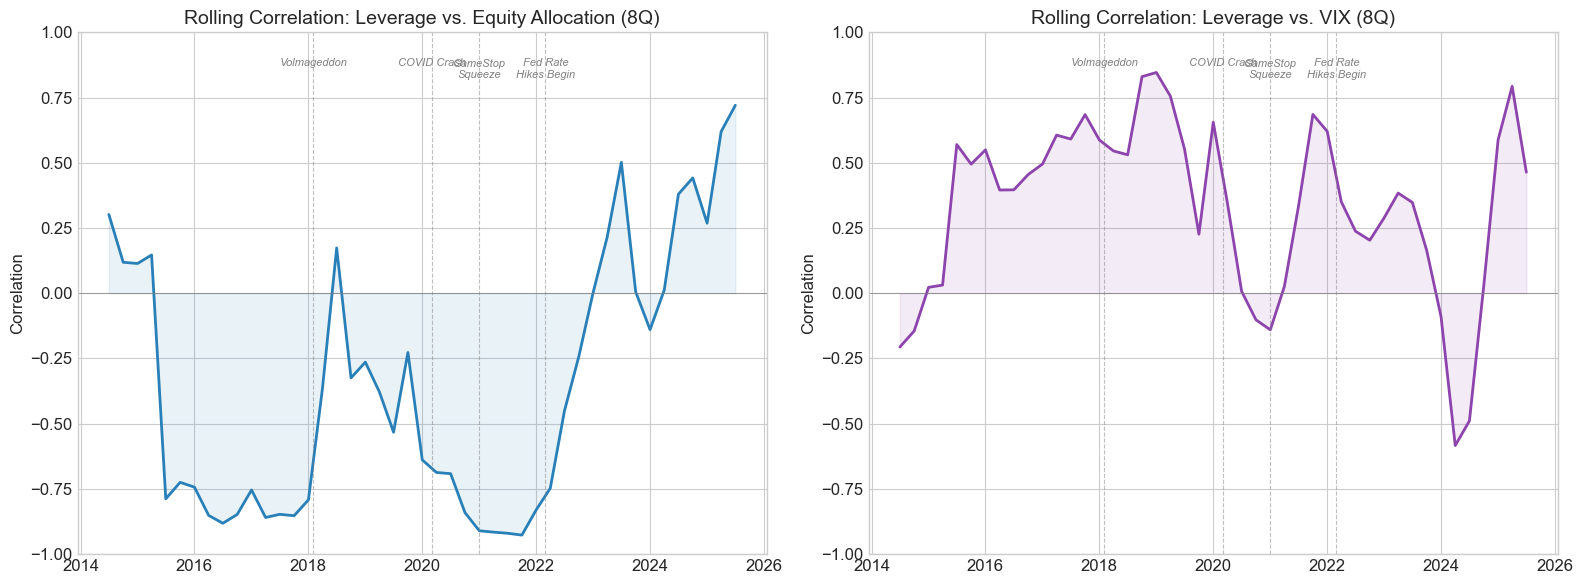

In [30]:
# Rolling correlations — leverage vs equity allocation, leverage vs VIX
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Leverage vs equity allocation (rolling 8-quarter correlation)
rolling_corr_eq = df["leverage_ratio"].rolling(8).corr(df["equity_pct"])
axes[0].plot(df.index, rolling_corr_eq, linewidth=2, color="#2980b9")
axes[0].axhline(0, color="gray", linewidth=0.5)
axes[0].fill_between(df.index, rolling_corr_eq, 0, alpha=0.1, color="#2980b9")
axes[0].set_title("Rolling Correlation: Leverage vs. Equity Allocation (8Q)")
axes[0].set_ylabel("Correlation")
axes[0].set_ylim(-1, 1)
add_event_annotations(axes[0])

# Leverage vs VIX (if available)
if "VIX_mean" in df_merged.columns:
    rolling_corr_vix = df_merged["leverage_ratio"].rolling(8).corr(df_merged["VIX_mean"])
    axes[1].plot(df_merged.index, rolling_corr_vix, linewidth=2, color="#8e44ad")
    axes[1].axhline(0, color="gray", linewidth=0.5)
    axes[1].fill_between(df_merged.index, rolling_corr_vix, 0, alpha=0.1, color="#8e44ad")
    axes[1].set_title("Rolling Correlation: Leverage vs. VIX (8Q)")
    axes[1].set_ylabel("Correlation")
    axes[1].set_ylim(-1, 1)
    add_event_annotations(axes[1])
else:
    axes[1].text(0.5, 0.5, "VIX data not available", ha="center", va="center", transform=axes[1].transAxes)

plt.tight_layout()
plt.show()

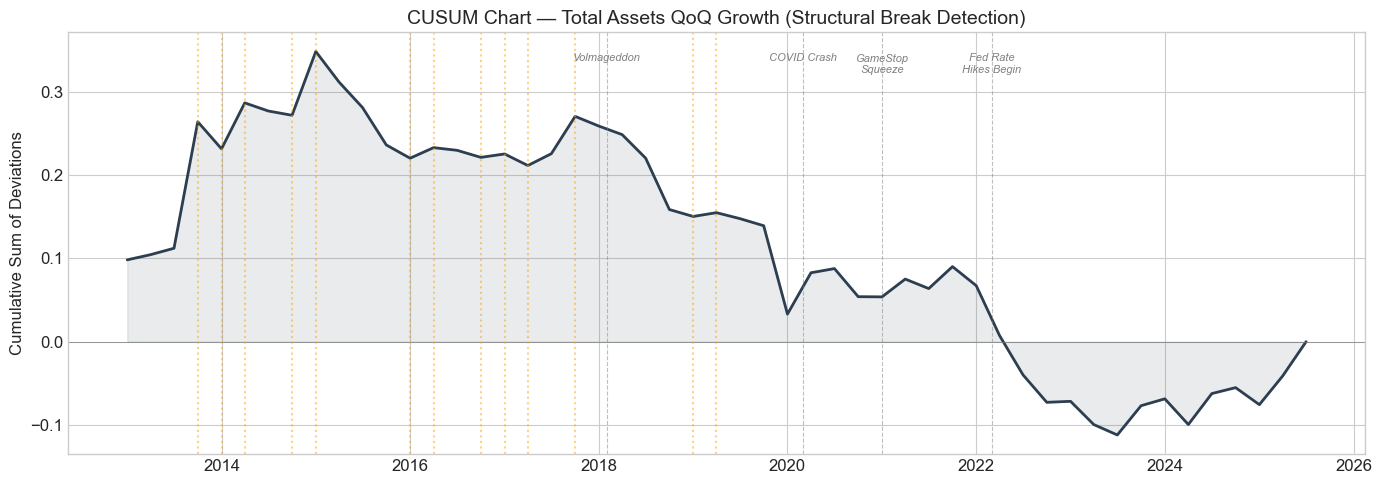

In [31]:
# Structural break detection — CUSUM on total assets growth
growth = df["total_assets_qoq"].dropna()

fig, ax = plt.subplots(figsize=(14, 5))

cumsum = np.cumsum(growth.values - growth.values.mean())
dates = growth.index

ax.plot(dates, cumsum, linewidth=2, color="#2c3e50")
ax.fill_between(dates, cumsum, 0, alpha=0.1, color="#2c3e50")
ax.axhline(0, color="gray", linewidth=0.5)
ax.set_title("CUSUM Chart — Total Assets QoQ Growth (Structural Break Detection)")
ax.set_ylabel("Cumulative Sum of Deviations")
add_event_annotations(ax)

# Identify potential break points
for i in range(2, len(cumsum) - 2):
    if (cumsum[i] > cumsum[i - 1] and cumsum[i] > cumsum[i + 1] and abs(cumsum[i]) > np.std(cumsum)) or (
        cumsum[i] < cumsum[i - 1] and cumsum[i] < cumsum[i + 1] and abs(cumsum[i]) > np.std(cumsum)
    ):
        ax.axvline(dates[i], color="orange", linestyle=":", alpha=0.5)

plt.tight_layout()
plt.show()

In [32]:
# Generate summary statistics for conclusions
print("=" * 70)
print("HEDGE FUND INDUSTRY ANALYSIS — KEY FINDINGS")
print("=" * 70)

first_q = f"{df.index.min().year} Q{df.index.min().quarter}"
last_q = f"{df.index.max().year} Q{df.index.max().quarter}"
print(f"\nPeriod: {first_q} to {last_q} ({len(df)} quarters)")

print("\n1. INDUSTRY GROWTH")
first_assets = df["Total assets"].iloc[0]
last_assets = df["Total assets"].iloc[-1]
years = len(df) / 4
if first_assets > 0:
    cagr = (last_assets / first_assets) ** (1 / years) - 1
    print(f"   Total assets grew from ${first_assets:,.0f}B to ${last_assets:,.0f}B")
    print(f"   CAGR: {cagr:.1%}")
else:
    print(f"   Total assets: ${last_assets:,.0f}B (latest)")
    print("   CAGR: N/A (no valid starting value)")

print("\n2. LEVERAGE TRENDS")
print(f"   Average leverage ratio: {df['leverage_ratio'].mean():.2f}x")
print(f"   Peak leverage: {df['leverage_ratio'].max():.2f}x ({df['leverage_ratio'].idxmax().date()})")
print(f"   Min leverage: {df['leverage_ratio'].min():.2f}x ({df['leverage_ratio'].idxmin().date()})")

print("\n3. ASSET ALLOCATION SHIFTS")
first_eq = df["equity_pct"].iloc[0]
last_eq = df["equity_pct"].iloc[-1]
print(f"   Equity allocation: {first_eq:.1%} → {last_eq:.1%}")
first_debt = df["debt_securities_pct"].iloc[0]
last_debt = df["debt_securities_pct"].iloc[-1]
print(f"   Debt securities:   {first_debt:.1%} → {last_debt:.1%}")

print("\n4. DERIVATIVE EXPOSURE")
print(f"   Average derivatives/assets: {df['derivative_to_assets'].mean():.1%}")
print(f"   Peak: {df['derivative_to_assets'].max():.1%} ({df['derivative_to_assets'].idxmax().date()})")

print("\n5. BORROWING PATTERNS")
print(
    f"   Foreign borrowing share: {df['foreign_borrowing_share'].iloc[0]:.1%} → {df['foreign_borrowing_share'].iloc[-1]:.1%}"
)
print(f"   Prime brokerage dominance: {df['prime_brokerage_pct'].mean():.1%} of total loans (avg)")

if not df_13f.empty and "value_thousands" in df_13f.columns:
    # Use latest quarter snapshot only (not pooled across filings)
    latest_q = df_13f["report_quarter"].max() if "report_quarter" in df_13f.columns else "all filings"
    df_snapshot = df_13f[df_13f["report_quarter"] == latest_q] if "report_quarter" in df_13f.columns else df_13f
    # Equity only (exclude puts/calls)
    df_eq = df_snapshot[df_snapshot["put_call"].isna() | (df_snapshot["put_call"] == "")]
    print(f"\n6. 13F HOLDINGS — {latest_q} snapshot ({df_eq['fund'].nunique()} funds)")
    print(f"   Equity positions: {len(df_eq):,}")
    top3 = df_eq.groupby("issuer")["value_thousands"].sum().nlargest(3)
    print(f"   Top 3 equity holdings: {', '.join(top3.index)}")

HEDGE FUND INDUSTRY ANALYSIS — KEY FINDINGS

Period: 2012 Q4 to 2025 Q3 (52 quarters)

1. INDUSTRY GROWTH
   Total assets grew from $1,145B to $3,258B
   CAGR: 8.4%

2. LEVERAGE TRENDS
   Average leverage ratio: 0.43x
   Peak leverage: 0.48x (2025-07-01)
   Min leverage: 0.40x (2017-04-01)

3. ASSET ALLOCATION SHIFTS
   Equity allocation: 33.9% → 42.0%
   Debt securities:   34.0% → 26.0%

4. DERIVATIVE EXPOSURE
   Average derivatives/assets: 56.2%
   Peak: 152.9% (2018-01-01)

5. BORROWING PATTERNS
   Foreign borrowing share: 14.8% → 16.9%
   Prime brokerage dominance: 78.3% of total loans (avg)

6. 13F HOLDINGS — 2021Q1 snapshot (8 funds)
   Equity positions: 17,759
   Top 3 equity holdings: APPLE INC, MICROSOFT CORP, ALPHABET INC


### Limitations

- **Aggregate vs. fund-level**: The Fed Z.1 data represents the entire domestic hedge fund sector (~1,000+ funds) — it masks wide variation across individual funds, strategies, and sizes. Form PF provides fund-level data but only for large advisers (>$1.5B AUM)
- **13F filing delays**: Holdings are reported ~45 days after quarter-end and only show long equity positions. Short positions are not disclosed
- **Survivorship bias**: Funds that close (like Melvin Capital) disappear from the aggregate data
- **Reporting thresholds**: Only institutional investment managers with >$100M in qualifying assets must file 13F reports
- **Cross-source timing**: Z.1 uses quarter-start dates, Form PF uses quarter labels, CFTC swaps are weekly, FCM data is monthly — alignment requires period-based joins that may introduce small timing mismatches

### Future Directions

- Add short-interest data (e.g., FINRA) to capture the short positioning invisible in 13F and Z.1
- Incorporate options flow data to reveal synthetic short exposure via puts
- Track hedge fund launches and closures to measure industry churn and survivorship effects
- Extend cross-source analysis to compare hedge fund leverage with broader financial sector leverage (banks, broker-dealers)
- Add non-U.S. hedge fund data for global industry comparison